In [1]:
# ============================================================
# PARKING SENSOR DATA - CELL 1
# LOAD DATASET AND BASIC STRUCTURE INSPECTION
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("PARKING SENSOR DATASET - INITIAL INSPECTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. File location
# ------------------------------------------------------------

parking_folder = r"C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\Parking"

parking_file = os.path.join(
    parking_folder,
    "on-street-parking-bay-sensors.csv"
)

print("\nFILE CHECK")
print("Parking folder exists:", os.path.exists(parking_folder))
print("Parking CSV exists:", os.path.exists(parking_file))

if not os.path.exists(parking_file):
    raise FileNotFoundError(
        f"Parking sensor dataset was not found:\n{parking_file}"
    )

# ------------------------------------------------------------
# 2. Load the raw dataset
# ------------------------------------------------------------

parking_raw = pd.read_csv(parking_file)

print("\nDataset loaded successfully.")

# ------------------------------------------------------------
# 3. Dataset dimensions
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET SIZE")
print("=" * 70)

print("Rows:", parking_raw.shape[0])
print("Columns:", parking_raw.shape[1])

# ------------------------------------------------------------
# 4. Column names
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for number, column in enumerate(parking_raw.columns, start=1):
    print(f"{number}. {column}")

# ------------------------------------------------------------
# 5. Data types
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(parking_raw.dtypes)

# ------------------------------------------------------------
# 6. First records
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIRST 10 RECORDS")
print("=" * 70)

display(parking_raw.head(10))

# ------------------------------------------------------------
# 7. General dataframe information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATAFRAME INFORMATION")
print("=" * 70)

parking_raw.info()

# ------------------------------------------------------------
# 8. Unique-value counts
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("UNIQUE VALUES PER COLUMN")
print("=" * 70)

unique_summary = pd.DataFrame({
    "Column": parking_raw.columns,
    "Unique_Values": [
        parking_raw[column].nunique(dropna=True)
        for column in parking_raw.columns
    ]
})

display(unique_summary)

print("\nCell 1 inspection completed.")

PARKING SENSOR DATASET - INITIAL INSPECTION

FILE CHECK
Parking folder exists: True
Parking CSV exists: True

Dataset loaded successfully.

DATASET SIZE
Rows: 6324
Columns: 6

COLUMN NAMES
1. Lastupdated
2. Status_Timestamp
3. Zone_Number
4. Status_Description
5. KerbsideID
6. Location

DATA TYPES
Lastupdated            object
Status_Timestamp       object
Zone_Number           float64
Status_Description     object
KerbsideID              int64
Location               object
dtype: object

FIRST 10 RECORDS


,Lastupdated,Status_Timestamp,Zone_Number,Status_Description,KerbsideID,Location
0,2024-12-30T11:44:37+11:00,2024-08-18T18:23:46+10:00,7394.0,Unoccupied,9344,"-37.80494402936792, 144.95916129121264"
1,2025-01-10T13:44:36+11:00,2024-08-14T19:22:05+10:00,7392.0,Unoccupied,9373,"-37.80329074425858, 144.95836336946644"
2,2024-12-05T10:44:37+11:00,2024-11-28T13:30:57+11:00,7084.0,Present,8735,"-37.80223335664963, 144.96120480793184"
3,2024-12-05T10:44:37+11:00,2024-11-28T10:23:40+11:00,7084.0,Unoccupied,8749,"-37.80230361629087, 144.9618505999636"
4,2025-01-09T16:44:36+11:00,2023-08-21T10:09:03+10:00,7800.0,Present,24505,"-37.79756250415984, 144.95759881813447"
5,2025-01-21T14:42:37+11:00,2025-01-20T16:57:00+11:00,7053.0,Present,10280,"-37.79502666258857, 144.97240204442983"
6,2025-06-04T09:44:34+10:00,2025-06-04T06:19:37+10:00,7986.0,Unoccupied,11137,"-37.80808044903779, 144.9546070339519"
7,2024-12-05T10:44:37+11:00,2024-11-28T14:03:02+11:00,7084.0,Present,8731,"-37.80221348499492, 144.96102904863818"
8,2024-12-05T10:44:37+11:00,2024-11-28T13:53:41+11:00,7084.0,Unoccupied,8736,"-37.802242080448615, 144.96129218606376"
9,2024-12-05T10:44:37+11:00,2024-11-28T13:57:26+11:00,7084.0,Unoccupied,8737,"-37.802245282357404, 144.9613214313597"



DATAFRAME INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6324 entries, 0 to 6323
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Lastupdated         6324 non-null   object 
 1   Status_Timestamp    6324 non-null   object 
 2   Zone_Number         5795 non-null   float64
 3   Status_Description  6324 non-null   object 
 4   KerbsideID          6324 non-null   int64  
 5   Location            6324 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 296.6+ KB

UNIQUE VALUES PER COLUMN


,Column,Unique_Values
0,Lastupdated,45
1,Status_Timestamp,6083
2,Zone_Number,536
3,Status_Description,2
4,KerbsideID,6324
5,Location,6193



Cell 1 inspection completed.


In [2]:
# ============================================================
# PARKING SENSOR DATA - CELL 2
# DATA QUALITY AND CONSISTENCY ASSESSMENT
# ============================================================

print("=" * 70)
print("PARKING SENSOR DATASET - DATA QUALITY ASSESSMENT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Missing values
# ------------------------------------------------------------

print("\nMISSING VALUES")

missing_summary = pd.DataFrame({
    "Column": parking_raw.columns,
    "Missing_Values": parking_raw.isna().sum().values,
    "Missing_Percentage": (
        parking_raw.isna().mean().values * 100
    ).round(2)
})

display(
    missing_summary.sort_values(
        "Missing_Values",
        ascending=False
    )
)

# ------------------------------------------------------------
# 2. Complete duplicate rows
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DUPLICATE RECORD CHECK")
print("=" * 70)

complete_duplicates = parking_raw.duplicated().sum()

print("Complete duplicate rows:", complete_duplicates)

if complete_duplicates > 0:
    print("\nExample duplicate records:")
    display(
        parking_raw[
            parking_raw.duplicated(keep=False)
        ].sort_values("KerbsideID").head(20)
    )

# ------------------------------------------------------------
# 3. Kerbside ID quality
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KERBSIDE ID CHECK")
print("=" * 70)

print("Total records:", len(parking_raw))
print(
    "Unique KerbsideIDs:",
    parking_raw["KerbsideID"].nunique()
)
print(
    "Missing KerbsideIDs:",
    parking_raw["KerbsideID"].isna().sum()
)
print(
    "Duplicated KerbsideIDs:",
    parking_raw["KerbsideID"].duplicated().sum()
)

# ------------------------------------------------------------
# 4. Parking status values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STATUS DESCRIPTION VALUES")
print("=" * 70)

status_summary = (
    parking_raw["Status_Description"]
    .value_counts(dropna=False)
    .rename_axis("Status_Description")
    .reset_index(name="Records")
)

status_summary["Percentage"] = (
    status_summary["Records"] / len(parking_raw) * 100
).round(2)

display(status_summary)

# ------------------------------------------------------------
# 5. Zone number quality
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ZONE NUMBER CHECK")
print("=" * 70)

print(
    "Records with Zone_Number:",
    parking_raw["Zone_Number"].notna().sum()
)
print(
    "Records without Zone_Number:",
    parking_raw["Zone_Number"].isna().sum()
)
print(
    "Unique populated zones:",
    parking_raw["Zone_Number"].nunique()
)

if parking_raw["Zone_Number"].notna().any():
    print(
        "Minimum zone number:",
        parking_raw["Zone_Number"].min()
    )
    print(
        "Maximum zone number:",
        parking_raw["Zone_Number"].max()
    )

# ------------------------------------------------------------
# 6. Check whether Zone_Number is integer-like
# ------------------------------------------------------------

populated_zones = parking_raw["Zone_Number"].dropna()

non_integer_zones = populated_zones[
    populated_zones % 1 != 0
]

print(
    "Non-integer Zone_Number values:",
    len(non_integer_zones)
)

# ------------------------------------------------------------
# 7. Location field consistency
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOCATION FIELD CHECK")
print("=" * 70)

print(
    "Missing locations:",
    parking_raw["Location"].isna().sum()
)

print(
    "Unique locations:",
    parking_raw["Location"].nunique()
)

print(
    "Records sharing an existing coordinate:",
    parking_raw["Location"].duplicated(keep=False).sum()
)

location_parts = parking_raw["Location"].str.split(
    ",",
    n=1,
    expand=True
)

print(
    "Location records successfully split into two parts:",
    location_parts.notna().all(axis=1).sum()
)

print(
    "Location records failing two-part split:",
    (~location_parts.notna().all(axis=1)).sum()
)

# ------------------------------------------------------------
# 8. Convert coordinates temporarily for validation only
# ------------------------------------------------------------

latitude_test = pd.to_numeric(
    location_parts[0].str.strip(),
    errors="coerce"
)

longitude_test = pd.to_numeric(
    location_parts[1].str.strip(),
    errors="coerce"
)

print("\nCOORDINATE PARSING")

print(
    "Valid latitude values:",
    latitude_test.notna().sum()
)

print(
    "Valid longitude values:",
    longitude_test.notna().sum()
)

print("\nCoordinate ranges:")

print(
    "Latitude:",
    latitude_test.min(),
    "to",
    latitude_test.max()
)

print(
    "Longitude:",
    longitude_test.min(),
    "to",
    longitude_test.max()
)

# ------------------------------------------------------------
# 9. Basic geographic validity
# ------------------------------------------------------------

valid_latitude = latitude_test.between(-90, 90)
valid_longitude = longitude_test.between(-180, 180)

print(
    "\nCoordinates outside valid latitude range:",
    (~valid_latitude).sum()
)

print(
    "Coordinates outside valid longitude range:",
    (~valid_longitude).sum()
)

# ------------------------------------------------------------
# 10. Raw timestamp string quality
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RAW TIMESTAMP FIELD CHECK")
print("=" * 70)

for column in ["Lastupdated", "Status_Timestamp"]:
    print(f"\n{column}")
    print("Missing values:", parking_raw[column].isna().sum())
    print("Unique values:", parking_raw[column].nunique())

    print(
        "Example earliest strings:",
        sorted(parking_raw[column].dropna().astype(str).unique())[:3]
    )

    print(
        "Example latest strings:",
        sorted(parking_raw[column].dropna().astype(str).unique())[-3:]
    )

print("\nCell 2 data-quality assessment completed.")

PARKING SENSOR DATASET - DATA QUALITY ASSESSMENT

MISSING VALUES


,Column,Missing_Values,Missing_Percentage
2,Zone_Number,529,8.36
0,Lastupdated,0,0.00
1,Status_Timestamp,0,0.00
3,Status_Description,0,0.00
4,KerbsideID,0,0.00
5,Location,0,0.00



DUPLICATE RECORD CHECK
Complete duplicate rows: 0

KERBSIDE ID CHECK
Total records: 6324
Unique KerbsideIDs: 6324
Missing KerbsideIDs: 0
Duplicated KerbsideIDs: 0

STATUS DESCRIPTION VALUES


,Status_Description,Records,Percentage
0,Unoccupied,4026,63.66
1,Present,2298,36.34



ZONE NUMBER CHECK
Records with Zone_Number: 5795
Records without Zone_Number: 529
Unique populated zones: 536
Minimum zone number: 7001.0
Maximum zone number: 7996.0
Non-integer Zone_Number values: 0

LOCATION FIELD CHECK
Missing locations: 0
Unique locations: 6193
Records sharing an existing coordinate: 262
Location records successfully split into two parts: 6324
Location records failing two-part split: 0

COORDINATE PARSING
Valid latitude values: 6324
Valid longitude values: 6324

Coordinate ranges:
Latitude: -37.84823801145724 to -37.79490584545896
Longitude: 144.93643568442775 to 144.9886119024162

Coordinates outside valid latitude range: 0
Coordinates outside valid longitude range: 0

RAW TIMESTAMP FIELD CHECK

Lastupdated
Missing values: 0
Unique values: 45
Example earliest strings: ['2024-12-05T10:44:37+11:00', '2024-12-11T15:44:36+11:00', '2024-12-30T11:44:37+11:00']
Example latest strings: ['2026-07-29T14:15:39+10:00', '2026-08-20T11:15:40+10:00', '2026-08-23T09:49:39+10:00'

In [3]:
# ============================================================
# PARKING SENSOR DATA - CELL 3
# TEMPORAL COVERAGE AND SENSOR FRESHNESS
# ============================================================

print("=" * 70)
print("PARKING SENSOR DATASET - TEMPORAL ASSESSMENT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create a working copy
# ------------------------------------------------------------

parking_work = parking_raw.copy()

print("\nWorking copy created.")
print("Records:", len(parking_work))

# ------------------------------------------------------------
# 2. Parse timezone-aware timestamps
#
# utc=True is used because the source contains both
# +10:00 and +11:00 Melbourne offsets.
# ------------------------------------------------------------

parking_work["Lastupdated_parsed"] = pd.to_datetime(
    parking_work["Lastupdated"],
    errors="coerce",
    utc=True
)

parking_work["Status_Timestamp_parsed"] = pd.to_datetime(
    parking_work["Status_Timestamp"],
    errors="coerce",
    utc=True
)

print("\nTIMESTAMP PARSING")

print(
    "Valid Lastupdated timestamps:",
    parking_work["Lastupdated_parsed"].notna().sum()
)

print(
    "Invalid Lastupdated timestamps:",
    parking_work["Lastupdated_parsed"].isna().sum()
)

print(
    "Valid Status_Timestamp values:",
    parking_work["Status_Timestamp_parsed"].notna().sum()
)

print(
    "Invalid Status_Timestamp values:",
    parking_work["Status_Timestamp_parsed"].isna().sum()
)

# ------------------------------------------------------------
# 3. Temporal coverage
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEMPORAL COVERAGE")
print("=" * 70)

print(
    "Earliest Lastupdated:",
    parking_work["Lastupdated_parsed"].min()
)

print(
    "Latest Lastupdated:",
    parking_work["Lastupdated_parsed"].max()
)

print(
    "\nEarliest Status_Timestamp:",
    parking_work["Status_Timestamp_parsed"].min()
)

print(
    "Latest Status_Timestamp:",
    parking_work["Status_Timestamp_parsed"].max()
)

# ------------------------------------------------------------
# 4. Calculate age of status relative to dataset update
#
# We use the latest Lastupdated timestamp in the dataset
# as the snapshot reference point.
# ------------------------------------------------------------

snapshot_time = parking_work["Lastupdated_parsed"].max()

parking_work["Status_Age_Days"] = (
    snapshot_time -
    parking_work["Status_Timestamp_parsed"]
).dt.total_seconds() / 86400

print("\n" + "=" * 70)
print("STATUS AGE RELATIVE TO DATASET SNAPSHOT")
print("=" * 70)

print("Snapshot reference time:", snapshot_time)

print(
    parking_work["Status_Age_Days"]
    .describe()
    .round(2)
)

# ------------------------------------------------------------
# 5. Check unusual timestamp relationships
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TIMESTAMP CONSISTENCY")
print("=" * 70)

future_status = (
    parking_work["Status_Timestamp_parsed"] >
    parking_work["Lastupdated_parsed"]
)

print(
    "Status timestamps later than their Lastupdated value:",
    future_status.sum()
)

negative_age = parking_work["Status_Age_Days"] < 0

print(
    "Status timestamps later than dataset snapshot:",
    negative_age.sum()
)

# ------------------------------------------------------------
# 6. Create freshness categories
# ------------------------------------------------------------

def classify_freshness(days):
    if pd.isna(days):
        return "Unknown"
    elif days <= 1:
        return "0-1 day"
    elif days <= 7:
        return "2-7 days"
    elif days <= 30:
        return "8-30 days"
    elif days <= 90:
        return "31-90 days"
    elif days <= 365:
        return "91-365 days"
    else:
        return "Over 1 year"


parking_work["Status_Freshness"] = (
    parking_work["Status_Age_Days"]
    .apply(classify_freshness)
)

freshness_order = [
    "0-1 day",
    "2-7 days",
    "8-30 days",
    "31-90 days",
    "91-365 days",
    "Over 1 year",
    "Unknown"
]

freshness_summary = (
    parking_work["Status_Freshness"]
    .value_counts()
    .reindex(freshness_order, fill_value=0)
    .rename_axis("Status_Freshness")
    .reset_index(name="Records")
)

freshness_summary["Percentage"] = (
    freshness_summary["Records"] /
    len(parking_work) * 100
).round(2)

print("\nSTATUS FRESHNESS DISTRIBUTION")

display(freshness_summary)

# ------------------------------------------------------------
# 7. Status timestamp distribution by year
# ------------------------------------------------------------

parking_work["Status_Year"] = (
    parking_work["Status_Timestamp_parsed"].dt.year
)

year_summary = (
    parking_work["Status_Year"]
    .value_counts()
    .sort_index()
    .rename_axis("Year")
    .reset_index(name="Records")
)

year_summary["Percentage"] = (
    year_summary["Records"] /
    len(parking_work) * 100
).round(2)

print("\n" + "=" * 70)
print("STATUS TIMESTAMP BY YEAR")
print("=" * 70)

display(year_summary)

# ------------------------------------------------------------
# 8. Status timestamp distribution by month
# ------------------------------------------------------------

parking_work["Status_YearMonth"] = (
    parking_work["Status_Timestamp_parsed"]
    .dt.strftime("%Y-%m")
)

month_summary = (
    parking_work["Status_YearMonth"]
    .value_counts()
    .sort_index()
    .rename_axis("Year_Month")
    .reset_index(name="Records")
)

print("\n" + "=" * 70)
print("STATUS TIMESTAMP BY MONTH")
print("=" * 70)

display(month_summary)

# ------------------------------------------------------------
# 9. Freshness by parking status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FRESHNESS BY PARKING STATUS")
print("=" * 70)

freshness_by_status = pd.crosstab(
    parking_work["Status_Freshness"],
    parking_work["Status_Description"]
)

freshness_by_status = freshness_by_status.reindex(
    freshness_order,
    fill_value=0
)

display(freshness_by_status)

# ------------------------------------------------------------
# 10. Oldest sensor-status records
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OLDEST SENSOR STATUS RECORDS")
print("=" * 70)

oldest_columns = [
    "KerbsideID",
    "Zone_Number",
    "Status_Description",
    "Status_Timestamp",
    "Lastupdated",
    "Status_Age_Days",
    "Location"
]

display(
    parking_work[
        oldest_columns
    ]
    .sort_values(
        "Status_Age_Days",
        ascending=False
    )
    .head(20)
)

print("\nCell 3 temporal assessment completed.")


PARKING SENSOR DATASET - TEMPORAL ASSESSMENT

Working copy created.
Records: 6324

TIMESTAMP PARSING
Valid Lastupdated timestamps: 6324
Invalid Lastupdated timestamps: 0
Valid Status_Timestamp values: 6324
Invalid Status_Timestamp values: 0

TEMPORAL COVERAGE
Earliest Lastupdated: 2024-12-04 23:44:37+00:00
Latest Lastupdated: 2026-08-22 23:49:39+00:00

Earliest Status_Timestamp: 2022-09-13 04:38:23+00:00
Latest Status_Timestamp: 2026-08-22 23:46:56+00:00

STATUS AGE RELATIVE TO DATASET SNAPSHOT
Snapshot reference time: 2026-08-22 23:49:39+00:00
count    6324.00
mean      130.82
std       238.57
min         0.00
25%         0.10
50%         7.12
75%       165.92
max      1439.80
Name: Status_Age_Days, dtype: float64

TIMESTAMP CONSISTENCY
Status timestamps later than their Lastupdated value: 0
Status timestamps later than dataset snapshot: 0

STATUS FRESHNESS DISTRIBUTION


,Status_Freshness,Records,Percentage
0,0-1 day,2904,45.92
1,2-7 days,111,1.76
2,8-30 days,1179,18.64
3,31-90 days,333,5.27
4,91-365 days,846,13.38
5,Over 1 year,951,15.04
6,Unknown,0,0.00



STATUS TIMESTAMP BY YEAR


,Year,Records,Percentage
0,2022,4,0.06
1,2023,82,1.30
2,2024,402,6.36
3,2025,907,14.34
4,2026,4929,77.94



STATUS TIMESTAMP BY MONTH


...


FRESHNESS BY PARKING STATUS


Status_Description,Present,Unoccupied
Status_Freshness,,
0-1 day,981,1923
2-7 days,40,71
8-30 days,266,913
31-90 days,117,216
91-365 days,459,387
Over 1 year,435,516
Unknown,0,0



OLDEST SENSOR STATUS RECORDS


,KerbsideID,Zone_Number,Status_Description,Status_Timestamp,Lastupdated,Status_Age_Days,Location
2259,17512,7247.0,Unoccupied,2022-09-13T14:38:23+10:00,2025-10-30T13:45:40+11:00,1439.799491,"-37.81092801328627, 144.97654350520963"
4843,9587,7725.0,Unoccupied,2022-11-20T14:44:07+11:00,2026-08-23T09:49:39+10:00,1371.837176,"-37.803844624328846, 144.9495796024437"
2234,23027,7258.0,Unoccupied,2022-11-30T10:10:24+11:00,2025-10-27T11:15:39+11:00,1362.027257,"-37.810537517616076, 144.97832033044642"
352,12076,7766.0,Unoccupied,2022-12-30T23:40:42+11:00,2026-08-23T09:49:39+10:00,1331.464549,"-37.80090875683292, 144.95327369052112"
3408,6547,NaN,Present,2023-01-14T10:58:09+11:00,2026-08-23T09:49:39+10:00,1316.994097,"-37.809835026066864, 144.95863398972602"
71,13140,7985.0,Unoccupied,2023-01-16T04:01:33+11:00,2025-06-13T09:44:34+10:00,1315.283403,"-37.80851645356166, 144.95258961438321"
4054,13134,7985.0,Unoccupied,2023-01-25T09:20:20+11:00,2026-08-23T09:49:39+10:00,1306.062025,"-37.80838428467885, 144.95304611092968"
2507,13457,7173.0,Unoccupied,2023-02-13T15:48:19+11:00,2026-08-23T09:49:39+10:00,1286.792593,"-37.81948453284795, 144.94501450488727"
4840,9581,7725.0,Unoccupied,2023-02-25T14:44:51+11:00,2026-08-23T09:49:39+10:00,1274.836667,"-37.80415783494985, 144.94952440572973"
4119,11124,7924.0,Present,2023-03-17T09:53:23+11:00,2026-08-23T09:49:39+10:00,1255.039074,"-37.80612299114207, 144.95209331580435"



Cell 3 temporal assessment completed.


PARKING SENSOR DATASET - SPATIAL PREPARATION

COORDINATE EXTRACTION
Valid latitude values: 6324
Valid longitude values: 6324
Missing latitude values: 0
Missing longitude values: 0

COORDINATE RANGES
Latitude: -37.84823801145724 to -37.79490584545896
Longitude: 144.93643568442775 to 144.9886119024162

PARKING GEODATAFRAME
Rows: 6324
CRS: EPSG:4326
Missing geometries: 0
Empty geometries: 0
Valid geometries: 6324

REPROJECTED PARKING DATA
Original CRS: EPSG:4326
Reprojected CRS: EPSG:7899

Projected bounds:
Minimum X: 2494403.102976052
Minimum Y: 2405868.528618322
Maximum X: 2498997.2492123684
Maximum Y: 2411787.4829499032

SHARED PARKING LOCATIONS
Unique coordinate locations: 6193
Locations containing more than one KerbsideID: 131
Maximum bays sharing one coordinate: 2
Total bays at shared coordinates: 262

Locations with most bays:


,Latitude,Longitude,Kerbside_Bays
1703,-37.815511,144.982564,2
3088,-37.811045,144.983320,2
3041,-37.811199,144.983295,2
3014,-37.811252,144.983286,2
2996,-37.811308,144.983277,2
2980,-37.811368,144.983267,2
2851,-37.811767,144.975098,2
2846,-37.811774,144.975165,2
2830,-37.811824,144.975634,2
2823,-37.811832,144.975706,2



ZONE-LEVEL PARKING STRUCTURE
Zones represented: 536
Minimum bays per zone: 1
Maximum bays per zone: 81
Median bays per zone: 7.0

Zones containing the most parking bays:


,Zone_Number,Parking_Bays,Unique_Locations,Present,Unoccupied,Mean_Status_Age_Days,Present_Percentage
151,7250.0,81,70,36,45,257.11,44.44
503,7918.0,74,74,31,43,2.01,41.89
11,7020.0,71,71,6,65,19.73,8.45
22,7043.0,65,65,10,55,8.14,15.38
150,7247.0,65,65,46,19,167.79,70.77
50,7084.0,63,63,13,50,277.49,20.63
475,7828.0,58,58,35,23,12.37,60.34
157,7258.0,54,54,12,42,156.31,22.22
18,7034.0,53,53,5,48,19.44,9.43
173,7280.0,51,43,15,36,61.73,29.41



BAYS WITHOUT ZONE NUMBERS
Bays without Zone_Number: 529
Unique locations among them: 527

Status distribution:


,Status,Records
0,Unoccupied,312
1,Present,217



APPROXIMATE GEOGRAPHIC CENTRE
Mean latitude: -37.811991
Mean longitude: 144.963125

BASIC PARKING SENSOR SPATIAL VIEW

SPATIAL WORKING DATASET
Parking records: 6324
Unique KerbsideIDs: 6324
CRS ready for PO comparison: EPSG:7899

Cell 4 spatial preparation completed.


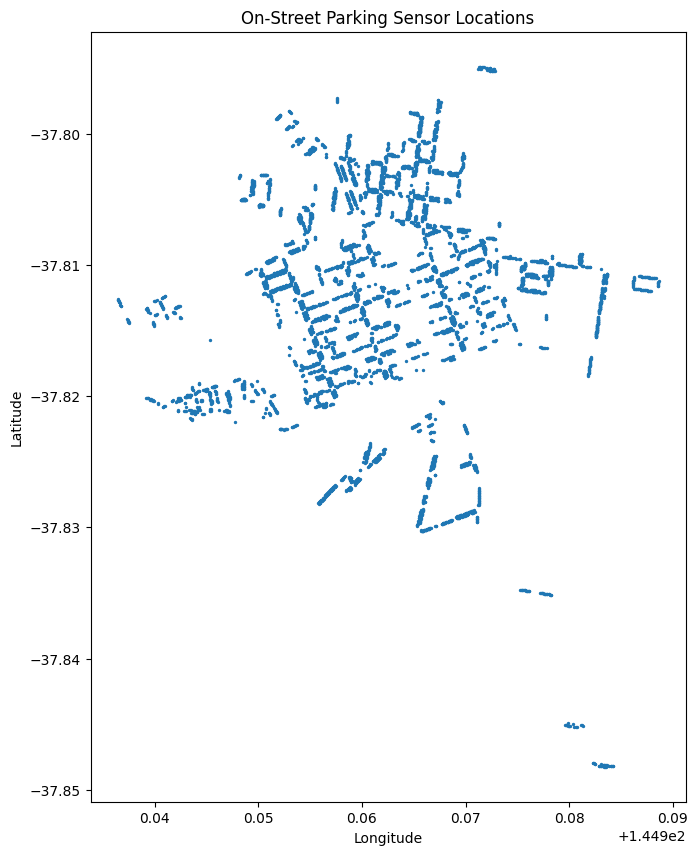

In [4]:
# ============================================================
# PARKING SENSOR DATA - CELL 4
# SPATIAL PREPARATION AND GEOGRAPHIC STRUCTURE
# ============================================================

import geopandas as gpd
from shapely.geometry import Point

print("=" * 70)
print("PARKING SENSOR DATASET - SPATIAL PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Extract latitude and longitude
# ------------------------------------------------------------

location_split = parking_work["Location"].str.split(
    ",",
    n=1,
    expand=True
)

parking_work["Latitude"] = pd.to_numeric(
    location_split[0].str.strip(),
    errors="coerce"
)

parking_work["Longitude"] = pd.to_numeric(
    location_split[1].str.strip(),
    errors="coerce"
)

print("\nCOORDINATE EXTRACTION")

print(
    "Valid latitude values:",
    parking_work["Latitude"].notna().sum()
)

print(
    "Valid longitude values:",
    parking_work["Longitude"].notna().sum()
)

print(
    "Missing latitude values:",
    parking_work["Latitude"].isna().sum()
)

print(
    "Missing longitude values:",
    parking_work["Longitude"].isna().sum()
)

# ------------------------------------------------------------
# 2. Coordinate ranges
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COORDINATE RANGES")
print("=" * 70)

print(
    "Latitude:",
    parking_work["Latitude"].min(),
    "to",
    parking_work["Latitude"].max()
)

print(
    "Longitude:",
    parking_work["Longitude"].min(),
    "to",
    parking_work["Longitude"].max()
)

# ------------------------------------------------------------
# 3. Create GeoDataFrame
#
# Latitude/longitude coordinates are initially interpreted
# using WGS84 (EPSG:4326).
# ------------------------------------------------------------

parking_gdf = gpd.GeoDataFrame(
    parking_work.copy(),
    geometry=gpd.points_from_xy(
        parking_work["Longitude"],
        parking_work["Latitude"]
    ),
    crs="EPSG:4326"
)

print("\n" + "=" * 70)
print("PARKING GEODATAFRAME")
print("=" * 70)

print("Rows:", len(parking_gdf))
print("CRS:", parking_gdf.crs)

print(
    "Missing geometries:",
    parking_gdf.geometry.isna().sum()
)

print(
    "Empty geometries:",
    parking_gdf.geometry.is_empty.sum()
)

print(
    "Valid geometries:",
    parking_gdf.geometry.is_valid.sum()
)

# ------------------------------------------------------------
# 4. Reproject to PO spatial CRS
#
# PO streets_spatial and study_area use EPSG:7899.
# Reprojecting allows valid spatial comparison.
# ------------------------------------------------------------

parking_gdf_7899 = parking_gdf.to_crs(
    epsg=7899
)

print("\n" + "=" * 70)
print("REPROJECTED PARKING DATA")
print("=" * 70)

print("Original CRS:", parking_gdf.crs)
print("Reprojected CRS:", parking_gdf_7899.crs)

print("\nProjected bounds:")

bounds = parking_gdf_7899.total_bounds

print("Minimum X:", bounds[0])
print("Minimum Y:", bounds[1])
print("Maximum X:", bounds[2])
print("Maximum Y:", bounds[3])

# ------------------------------------------------------------
# 5. Shared coordinate analysis
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SHARED PARKING LOCATIONS")
print("=" * 70)

location_counts = (
    parking_work
    .groupby(["Latitude", "Longitude"])
    .size()
    .reset_index(name="Kerbside_Bays")
)

shared_locations = location_counts[
    location_counts["Kerbside_Bays"] > 1
].copy()

print(
    "Unique coordinate locations:",
    len(location_counts)
)

print(
    "Locations containing more than one KerbsideID:",
    len(shared_locations)
)

print(
    "Maximum bays sharing one coordinate:",
    location_counts["Kerbside_Bays"].max()
)

print(
    "Total bays at shared coordinates:",
    shared_locations["Kerbside_Bays"].sum()
)

if len(shared_locations) > 0:
    print("\nLocations with most bays:")
    
    display(
        shared_locations
        .sort_values(
            "Kerbside_Bays",
            ascending=False
        )
        .head(20)
    )

# ------------------------------------------------------------
# 6. Zone-level structure
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ZONE-LEVEL PARKING STRUCTURE")
print("=" * 70)

zone_summary = (
    parking_work
    .dropna(subset=["Zone_Number"])
    .groupby("Zone_Number")
    .agg(
        Parking_Bays=("KerbsideID", "nunique"),
        Unique_Locations=("Location", "nunique"),
        Present=("Status_Description",
                 lambda x: (x == "Present").sum()),
        Unoccupied=("Status_Description",
                    lambda x: (x == "Unoccupied").sum()),
        Mean_Status_Age_Days=("Status_Age_Days", "mean")
    )
    .reset_index()
)

zone_summary["Present_Percentage"] = (
    zone_summary["Present"] /
    zone_summary["Parking_Bays"] * 100
).round(2)

zone_summary["Mean_Status_Age_Days"] = (
    zone_summary["Mean_Status_Age_Days"]
    .round(2)
)

print("Zones represented:", len(zone_summary))

print(
    "Minimum bays per zone:",
    zone_summary["Parking_Bays"].min()
)

print(
    "Maximum bays per zone:",
    zone_summary["Parking_Bays"].max()
)

print(
    "Median bays per zone:",
    zone_summary["Parking_Bays"].median()
)

print("\nZones containing the most parking bays:")

display(
    zone_summary
    .sort_values(
        "Parking_Bays",
        ascending=False
    )
    .head(20)
)

# ------------------------------------------------------------
# 7. Bays without zone numbers
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BAYS WITHOUT ZONE NUMBERS")
print("=" * 70)

missing_zone = parking_work[
    parking_work["Zone_Number"].isna()
].copy()

print("Bays without Zone_Number:", len(missing_zone))

print(
    "Unique locations among them:",
    missing_zone["Location"].nunique()
)

print("\nStatus distribution:")

display(
    missing_zone["Status_Description"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Records")
)

# ------------------------------------------------------------
# 8. Geographic centre
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("APPROXIMATE GEOGRAPHIC CENTRE")
print("=" * 70)

print(
    "Mean latitude:",
    round(parking_work["Latitude"].mean(), 6)
)

print(
    "Mean longitude:",
    round(parking_work["Longitude"].mean(), 6)
)

# ------------------------------------------------------------
# 9. Basic spatial view
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BASIC PARKING SENSOR SPATIAL VIEW")
print("=" * 70)

ax = parking_gdf.plot(
    figsize=(8, 10),
    markersize=2
)

ax.set_title(
    "On-Street Parking Sensor Locations"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ------------------------------------------------------------
# 10. Working dataset check
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SPATIAL WORKING DATASET")
print("=" * 70)

print(
    "Parking records:",
    len(parking_gdf_7899)
)

print(
    "Unique KerbsideIDs:",
    parking_gdf_7899["KerbsideID"].nunique()
)

print(
    "CRS ready for PO comparison:",
    parking_gdf_7899.crs
)

print("\nCell 4 spatial preparation completed.")

PARKING SENSOR DATASET - ZONE SPATIAL ANALYSIS

ZONE FILTERING
----------------------------------------------------------------------
Total parking bays: 6324
Bays with Zone_Number: 5795
Bays without Zone_Number: 529
Unique zones available: 536

ZONE SPATIAL SUMMARY
Zones summarised: 536
Average bays per zone: 10.81
Median bays per zone: 7.0
Largest zone: 81 bays

CURRENT STATUS BY ZONE
Mean zone present percentage: 36.12
Median zone present percentage: 33.33

20 ZONES WITH MOST PARKING BAYS


,Zone_Number,Parking_Bays,Unique_Locations,Present,Unoccupied,Present_Percentage,Mean_Latitude,Mean_Longitude
151,7250.0,81,70,36,45,44.444444,-37.813032,144.982986
503,7918.0,74,74,31,43,41.891892,-37.810683,144.951729
11,7020.0,71,71,6,65,8.450704,-37.803295,144.961978
22,7043.0,65,65,10,55,15.384615,-37.805703,144.964583
150,7247.0,65,65,46,19,70.769231,-37.810821,144.976720
50,7084.0,63,63,13,50,20.634921,-37.802238,144.961385
475,7828.0,58,58,35,23,60.344828,-37.829013,144.969987
157,7258.0,54,54,12,42,22.222222,-37.810624,144.978194
18,7034.0,53,53,5,48,9.433962,-37.799497,144.965630
173,7280.0,51,43,15,36,29.411765,-37.811944,144.976130



ZONE CENTRE GEODATAFRAME
Zone centre records: 536
CRS: EPSG:7899
Valid geometries: 536


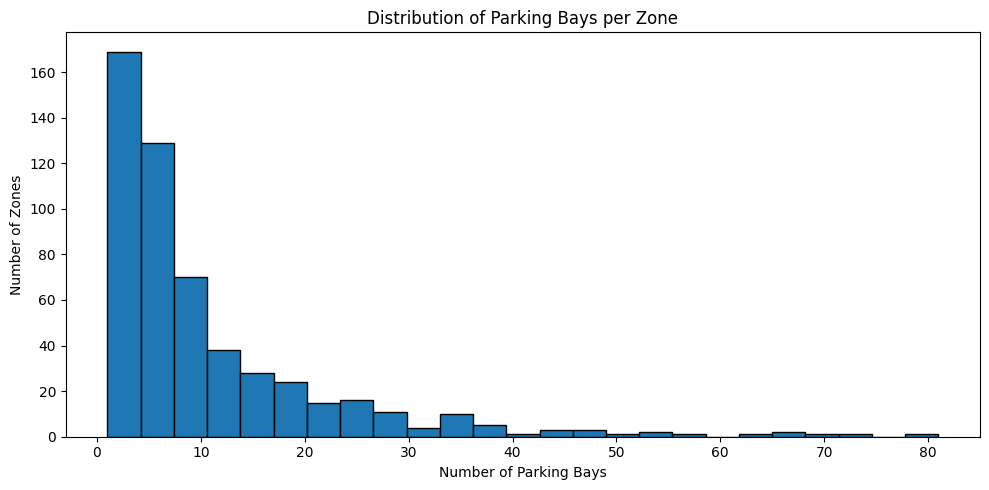

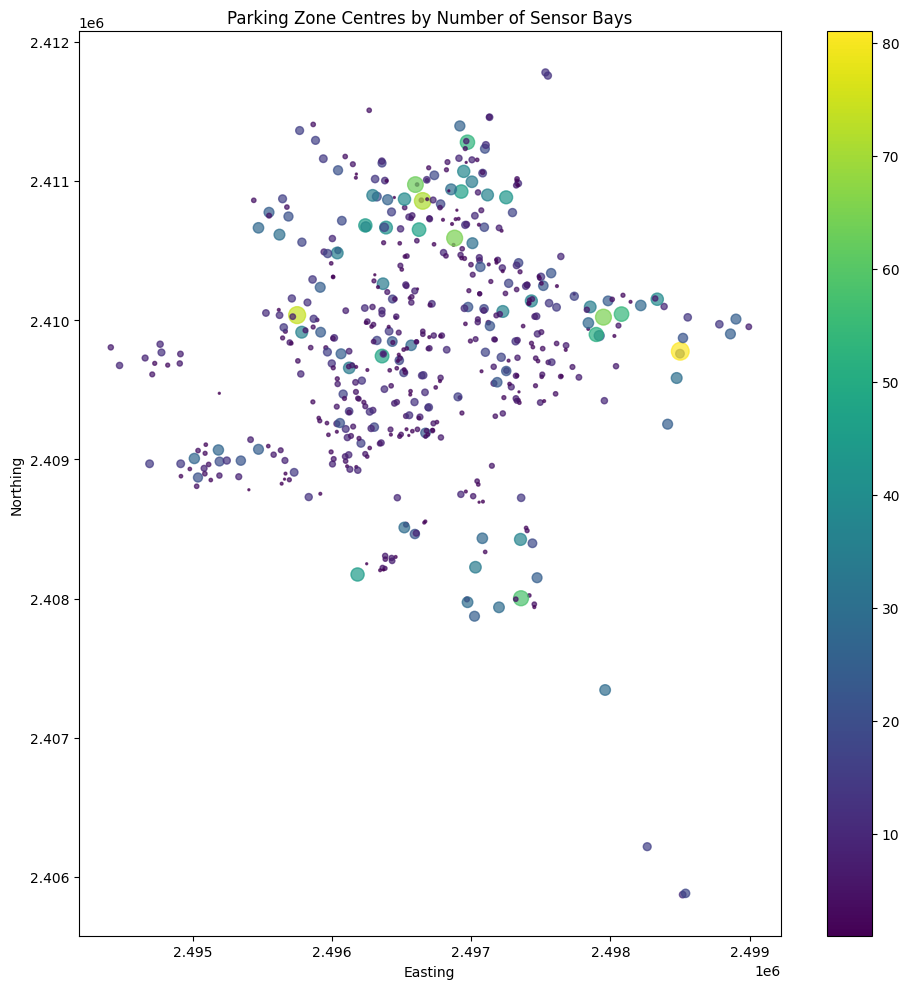


CELL 5 OUTPUT DATASETS
parking_zoned: 5795 parking bays
zone_spatial_summary: 536 zones
zone_centres_7899: 536 zone centre points

Cell 5 zone spatial analysis completed.


In [5]:
# ============================================================
# CELL 5 - PARKING ZONE SPATIAL ANALYSIS
# ============================================================

print("=" * 70)
print("PARKING SENSOR DATASET - ZONE SPATIAL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. KEEP RECORDS WITH VALID ZONE NUMBERS
# ------------------------------------------------------------

parking_zoned = parking_gdf[
    parking_gdf["Zone_Number"].notna()
].copy()

print("\nZONE FILTERING")
print("-" * 70)

print("Total parking bays:", len(parking_gdf))
print("Bays with Zone_Number:", len(parking_zoned))
print(
    "Bays without Zone_Number:",
    parking_gdf["Zone_Number"].isna().sum()
)

print(
    "Unique zones available:",
    parking_zoned["Zone_Number"].nunique()
)


# ------------------------------------------------------------
# 2. CREATE ZONE-LEVEL SPATIAL SUMMARY
# ------------------------------------------------------------

zone_spatial_summary = (
    parking_zoned
    .groupby("Zone_Number")
    .agg(
        Parking_Bays=("KerbsideID", "nunique"),
        Unique_Locations=("Location", "nunique"),
        Mean_Latitude=("Latitude", "mean"),
        Mean_Longitude=("Longitude", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("ZONE SPATIAL SUMMARY")
print("=" * 70)

print("Zones summarised:", len(zone_spatial_summary))

print(
    "Average bays per zone:",
    round(zone_spatial_summary["Parking_Bays"].mean(), 2)
)

print(
    "Median bays per zone:",
    round(zone_spatial_summary["Parking_Bays"].median(), 2)
)

print(
    "Largest zone:",
    int(zone_spatial_summary["Parking_Bays"].max()),
    "bays"
)


# ------------------------------------------------------------
# 3. ADD CURRENT PARKING STATUS COUNTS
# ------------------------------------------------------------

status_by_zone = (
    parking_zoned
    .groupby(["Zone_Number", "Status_Description"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

zone_spatial_summary = zone_spatial_summary.merge(
    status_by_zone,
    on="Zone_Number",
    how="left"
)

# Make sure both status columns exist
if "Present" not in zone_spatial_summary.columns:
    zone_spatial_summary["Present"] = 0

if "Unoccupied" not in zone_spatial_summary.columns:
    zone_spatial_summary["Unoccupied"] = 0


# ------------------------------------------------------------
# 4. CALCULATE PRESENT PERCENTAGE
# ------------------------------------------------------------

zone_spatial_summary["Present_Percentage"] = (
    zone_spatial_summary["Present"]
    / zone_spatial_summary["Parking_Bays"]
    * 100
)

print("\n" + "=" * 70)
print("CURRENT STATUS BY ZONE")
print("=" * 70)

print(
    "Mean zone present percentage:",
    round(
        zone_spatial_summary["Present_Percentage"].mean(),
        2
    )
)

print(
    "Median zone present percentage:",
    round(
        zone_spatial_summary["Present_Percentage"].median(),
        2
    )
)


# ------------------------------------------------------------
# 5. SHOW ZONES WITH MOST PARKING BAYS
# ------------------------------------------------------------

largest_zones = (
    zone_spatial_summary
    .sort_values(
        "Parking_Bays",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 70)
print("20 ZONES WITH MOST PARKING BAYS")
print("=" * 70)

display(
    largest_zones[
        [
            "Zone_Number",
            "Parking_Bays",
            "Unique_Locations",
            "Present",
            "Unoccupied",
            "Present_Percentage",
            "Mean_Latitude",
            "Mean_Longitude"
        ]
    ]
)


# ------------------------------------------------------------
# 6. CREATE ZONE CENTRE GEODATAFRAME
# ------------------------------------------------------------

zone_centres = gpd.GeoDataFrame(
    zone_spatial_summary,
    geometry=gpd.points_from_xy(
        zone_spatial_summary["Mean_Longitude"],
        zone_spatial_summary["Mean_Latitude"]
    ),
    crs="EPSG:4326"
)

zone_centres_7899 = zone_centres.to_crs("EPSG:7899")

print("\n" + "=" * 70)
print("ZONE CENTRE GEODATAFRAME")
print("=" * 70)

print("Zone centre records:", len(zone_centres_7899))
print("CRS:", zone_centres_7899.crs)
print(
    "Valid geometries:",
    zone_centres_7899.geometry.notna().sum()
)


# ------------------------------------------------------------
# 7. PARKING BAY DISTRIBUTION BY ZONE
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    zone_spatial_summary["Parking_Bays"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Parking Bays per Zone")
plt.xlabel("Number of Parking Bays")
plt.ylabel("Number of Zones")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. SPATIAL VIEW OF ZONE CENTRES
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

zone_centres_7899.plot(
    ax=ax,
    column="Parking_Bays",
    markersize=(
        zone_centres_7899["Parking_Bays"] * 2
    ),
    legend=True,
    alpha=0.7
)

ax.set_title(
    "Parking Zone Centres by Number of Sensor Bays"
)

ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 5 OUTPUT DATASETS")
print("=" * 70)

print(
    "parking_zoned:",
    len(parking_zoned),
    "parking bays"
)

print(
    "zone_spatial_summary:",
    len(zone_spatial_summary),
    "zones"
)

print(
    "zone_centres_7899:",
    len(zone_centres_7899),
    "zone centre points"
)

print("\nCell 5 zone spatial analysis completed.")

PARKING SENSOR DATASET - CURRENT PARKING PRESSURE ANALYSIS

INPUT DATA CHECK
----------------------------------------------------------------------
Parking records: 6324
Zone summary records: 536
Zone centre records: 536
Zone centre CRS: EPSG:7899

ZONE PRESSURE PREPARATION
Zones available: 536

UNOCCUPIED PARKING PERCENTAGE
----------------------------------------------------------------------
Mean unoccupied percentage: 63.88
Median unoccupied percentage: 66.67
Minimum unoccupied percentage: 0.0
Maximum unoccupied percentage: 100.0

PARKING PRESSURE SCORE
Mean pressure score: 36.12
Median pressure score: 33.33
Minimum pressure score: 0.0
Maximum pressure score: 100.0

PRESSURE CATEGORY DISTRIBUTION
Pressure_Category
Low          216
Moderate     133
High         121
Very High     66
Name: count, dtype: int32

20 ZONES WITH HIGHEST CURRENT PARKING PRESSURE
 Zone_Number  Parking_Bays  Present  Unoccupied  Present_Percentage  Unoccupied_Percentage  Pressure_Score Pressure_Category
     

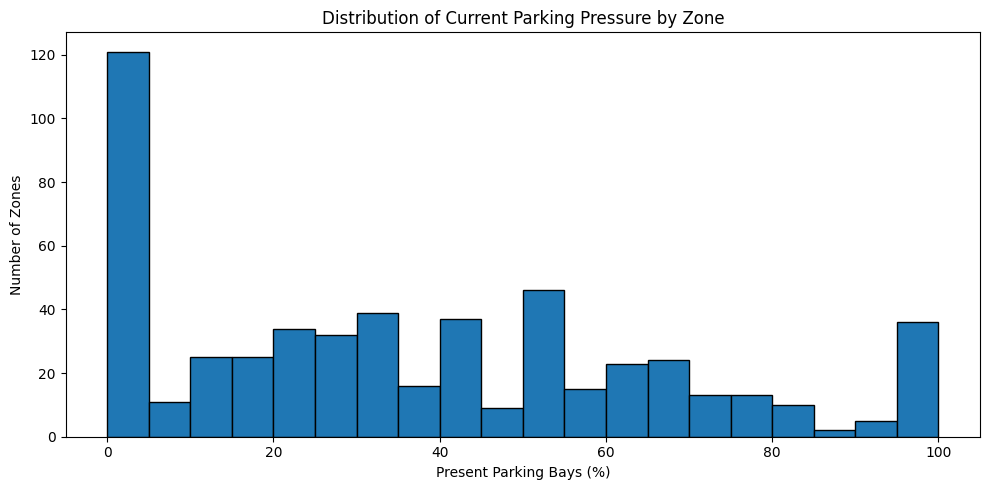

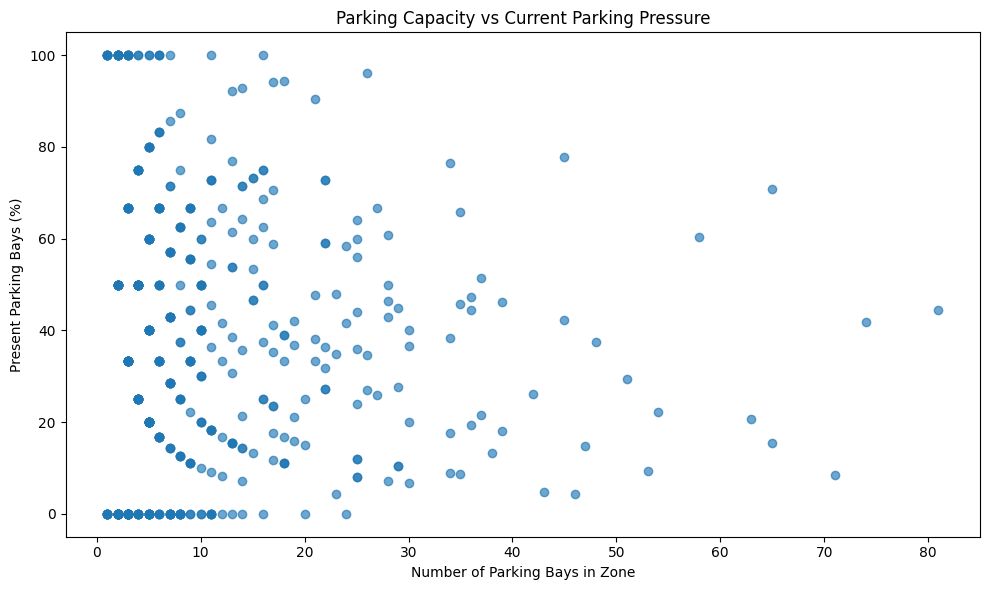


PRESSURE MAP DATASET
Zone records: 536
CRS: EPSG:7899
Valid geometries: 536
Missing pressure scores: 0

Columns available:
['Zone_Number', 'Parking_Bays', 'Unique_Locations', 'Mean_Latitude', 'Mean_Longitude', 'Present', 'Unoccupied', 'Present_Percentage', 'geometry', 'Unoccupied_Percentage', 'Pressure_Score', 'Pressure_Category']


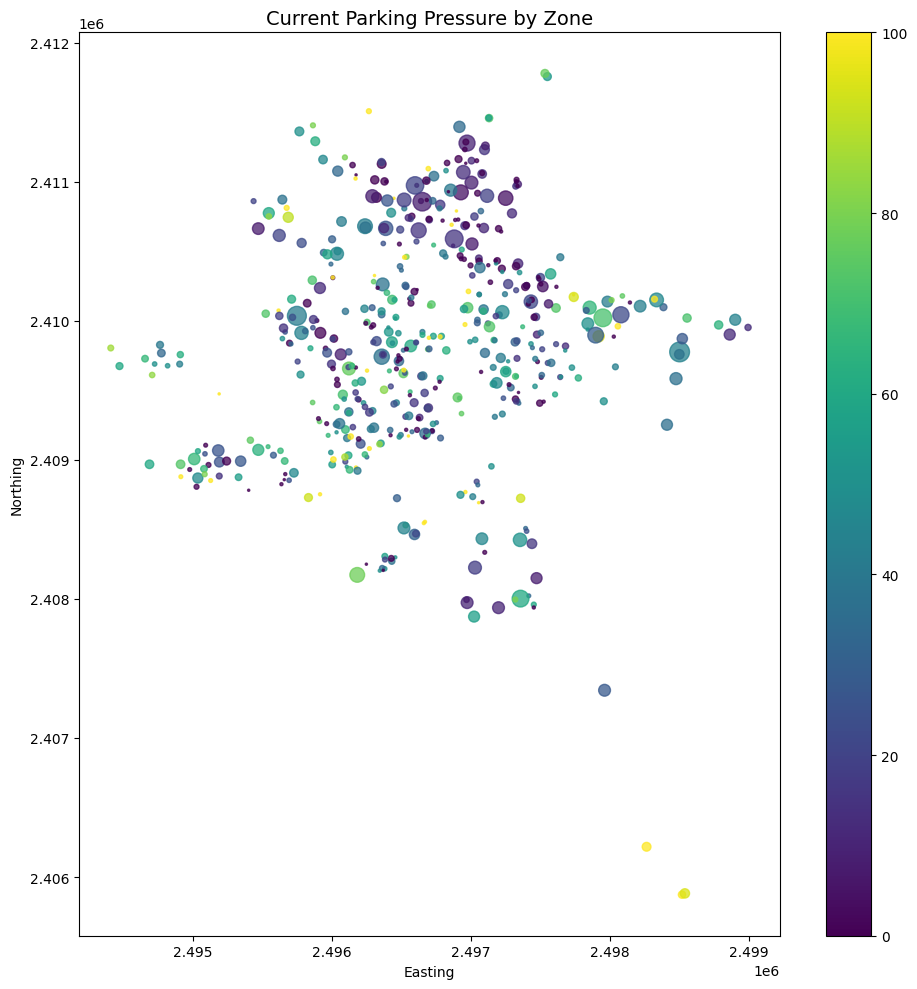

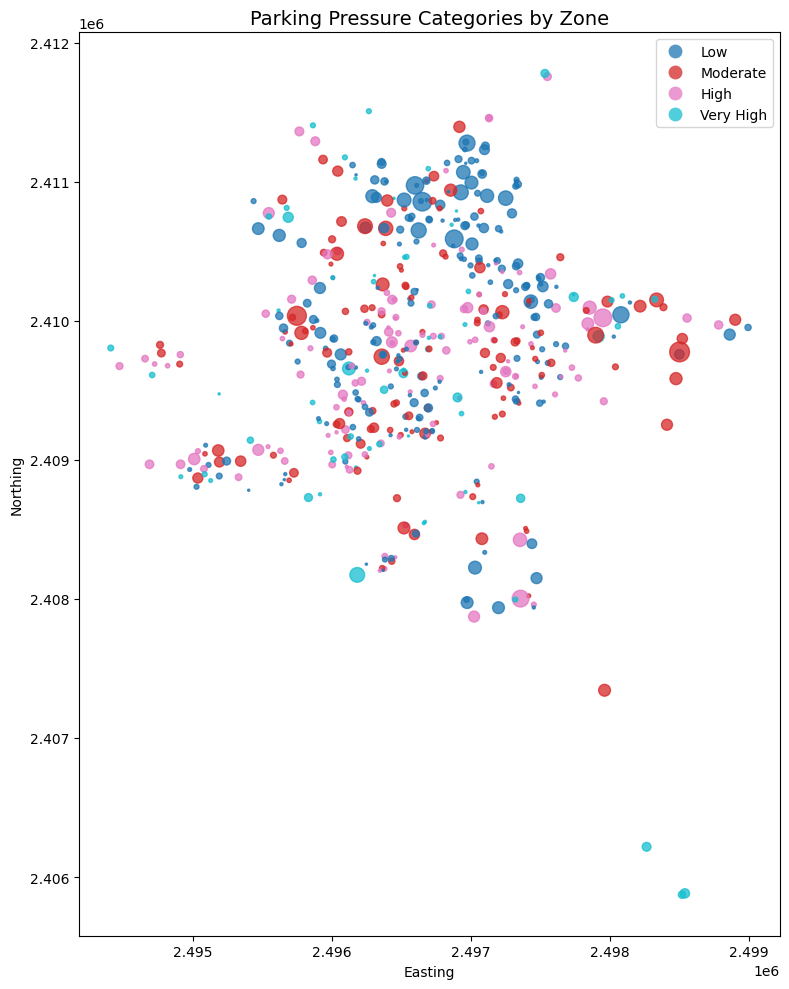


HIGH PRESSURE ZONES WITH MEANINGFUL PARKING CAPACITY
Minimum parking bays used for this comparison: 7.0
 Zone_Number  Parking_Bays  Present  Unoccupied  Present_Percentage  Unoccupied_Percentage  Pressure_Score Pressure_Category
      7910.0            16       16           0          100.000000                   0.00          100.00         Very High
      7584.0            11       11           0          100.000000                   0.00          100.00         Very High
      7252.0             7        7           0          100.000000                   0.00          100.00         Very High
      7278.0            26       25           1           96.153846                   3.85           96.15         Very High
      7586.0            18       17           1           94.444444                   5.56           94.44         Very High
      7245.0            17       16           1           94.117647                   5.88           94.12         Very High
      7650.0        

In [6]:
# ============================================================
# CELL 6 - PARKING SENSOR DATASET: CURRENT PARKING PRESSURE
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt


print("=" * 70)
print("PARKING SENSOR DATASET - CURRENT PARKING PRESSURE ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. CHECK REQUIRED DATASETS
# ------------------------------------------------------------

required_objects = [
    "parking_gdf_7899",
    "zone_spatial_summary",
    "zone_centres_7899"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following datasets are missing. "
        "Please run the previous cells first: "
        + ", ".join(missing_objects)
    )

print("\nINPUT DATA CHECK")
print("-" * 70)

print("Parking records:", len(parking_gdf_7899))
print("Zone summary records:", len(zone_spatial_summary))
print("Zone centre records:", len(zone_centres_7899))
print("Zone centre CRS:", zone_centres_7899.crs)


# ------------------------------------------------------------
# 2. PREPARE ZONE PRESSURE DATA
# ------------------------------------------------------------

zone_pressure = zone_spatial_summary.copy()

print("\n" + "=" * 70)
print("ZONE PRESSURE PREPARATION")
print("=" * 70)

print("Zones available:", len(zone_pressure))


# ------------------------------------------------------------
# 3. CALCULATE UNOCCUPIED PERCENTAGE
# ------------------------------------------------------------

zone_pressure["Unoccupied_Percentage"] = (
    zone_pressure["Unoccupied"]
    / zone_pressure["Parking_Bays"]
) * 100

zone_pressure["Unoccupied_Percentage"] = (
    zone_pressure["Unoccupied_Percentage"]
    .round(2)
)

print("\nUNOCCUPIED PARKING PERCENTAGE")
print("-" * 70)

print(
    "Mean unoccupied percentage:",
    round(
        zone_pressure["Unoccupied_Percentage"].mean(),
        2
    )
)

print(
    "Median unoccupied percentage:",
    round(
        zone_pressure["Unoccupied_Percentage"].median(),
        2
    )
)

print(
    "Minimum unoccupied percentage:",
    round(
        zone_pressure["Unoccupied_Percentage"].min(),
        2
    )
)

print(
    "Maximum unoccupied percentage:",
    round(
        zone_pressure["Unoccupied_Percentage"].max(),
        2
    )
)


# ------------------------------------------------------------
# 4. CREATE PARKING PRESSURE SCORE
# ------------------------------------------------------------
#
# Present_Percentage measures how many bays currently show
# vehicles as present.
#
# A higher percentage therefore represents greater current
# parking usage / pressure.
#
# For this first baseline analysis, the pressure score is kept
# simple and interpretable by using Present_Percentage directly.
# ------------------------------------------------------------

zone_pressure["Pressure_Score"] = (
    zone_pressure["Present_Percentage"]
    .clip(lower=0, upper=100)
    .round(2)
)

print("\n" + "=" * 70)
print("PARKING PRESSURE SCORE")
print("=" * 70)

print(
    "Mean pressure score:",
    round(
        zone_pressure["Pressure_Score"].mean(),
        2
    )
)

print(
    "Median pressure score:",
    round(
        zone_pressure["Pressure_Score"].median(),
        2
    )
)

print(
    "Minimum pressure score:",
    round(
        zone_pressure["Pressure_Score"].min(),
        2
    )
)

print(
    "Maximum pressure score:",
    round(
        zone_pressure["Pressure_Score"].max(),
        2
    )
)


# ------------------------------------------------------------
# 5. CLASSIFY PARKING PRESSURE
# ------------------------------------------------------------
#
# Categories are descriptive rather than predictive.
#
# Low       = less than 25% of bays present
# Moderate  = 25% to less than 50%
# High      = 50% to less than 75%
# Very High = 75% or above
# ------------------------------------------------------------

pressure_bins = [
    -np.inf,
    25,
    50,
    75,
    np.inf
]

pressure_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

zone_pressure["Pressure_Category"] = pd.cut(
    zone_pressure["Pressure_Score"],
    bins=pressure_bins,
    labels=pressure_labels,
    right=False
)

print("\n" + "=" * 70)
print("PRESSURE CATEGORY DISTRIBUTION")
print("=" * 70)

pressure_distribution = (
    zone_pressure["Pressure_Category"]
    .value_counts()
    .reindex(pressure_labels)
    .fillna(0)
    .astype(int)
)

print(pressure_distribution)


# ------------------------------------------------------------
# 6. IDENTIFY HIGHEST PRESSURE ZONES
# ------------------------------------------------------------

highest_pressure_zones = (
    zone_pressure
    .sort_values(
        by=[
            "Pressure_Score",
            "Parking_Bays"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(20)
)

print("\n" + "=" * 70)
print("20 ZONES WITH HIGHEST CURRENT PARKING PRESSURE")
print("=" * 70)

high_pressure_columns = [
    "Zone_Number",
    "Parking_Bays",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Unoccupied_Percentage",
    "Pressure_Score",
    "Pressure_Category"
]

print(
    highest_pressure_zones[
        high_pressure_columns
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 7. IDENTIFY LOWEST PRESSURE ZONES
# ------------------------------------------------------------

lowest_pressure_zones = (
    zone_pressure
    .sort_values(
        by=[
            "Pressure_Score",
            "Parking_Bays"
        ],
        ascending=[
            True,
            False
        ]
    )
    .head(20)
)

print("\n" + "=" * 70)
print("20 ZONES WITH LOWEST CURRENT PARKING PRESSURE")
print("=" * 70)

print(
    lowest_pressure_zones[
        high_pressure_columns
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 8. PRESSURE DISTRIBUTION GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    zone_pressure["Pressure_Score"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title(
    "Distribution of Current Parking Pressure by Zone"
)

plt.xlabel(
    "Present Parking Bays (%)"
)

plt.ylabel(
    "Number of Zones"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. PARKING CAPACITY VS CURRENT PRESSURE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    zone_pressure["Parking_Bays"],
    zone_pressure["Pressure_Score"],
    alpha=0.65
)

plt.title(
    "Parking Capacity vs Current Parking Pressure"
)

plt.xlabel(
    "Number of Parking Bays in Zone"
)

plt.ylabel(
    "Present Parking Bays (%)"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. CREATE GEOSPATIAL PRESSURE DATASET
# ------------------------------------------------------------
#
# IMPORTANT:
# zone_centres_7899 already contains Parking_Bays and other
# summary variables from Cell 5.
#
# Therefore, only the NEW pressure-related variables are merged.
# This prevents duplicate columns such as:
#
# Parking_Bays_x
# Parking_Bays_y
#
# which caused the previous KeyError.
# ------------------------------------------------------------

pressure_columns = [
    "Zone_Number",
    "Unoccupied_Percentage",
    "Pressure_Score",
    "Pressure_Category"
]

pressure_map = zone_centres_7899.merge(
    zone_pressure[
        pressure_columns
    ],
    on="Zone_Number",
    how="left"
)

pressure_map = gpd.GeoDataFrame(
    pressure_map,
    geometry="geometry",
    crs=zone_centres_7899.crs
)


print("\n" + "=" * 70)
print("PRESSURE MAP DATASET")
print("=" * 70)

print(
    "Zone records:",
    len(pressure_map)
)

print(
    "CRS:",
    pressure_map.crs
)

print(
    "Valid geometries:",
    pressure_map.geometry.notna().sum()
)

print(
    "Missing pressure scores:",
    pressure_map[
        "Pressure_Score"
    ].isna().sum()
)

print("\nColumns available:")
print(
    pressure_map.columns.tolist()
)


# ------------------------------------------------------------
# 11. MAP CURRENT PARKING PRESSURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

pressure_map.plot(
    ax=ax,
    column="Pressure_Score",
    markersize=(
        pressure_map["Parking_Bays"]
        .fillna(1)
        .clip(lower=1)
        * 2.5
    ),
    legend=True,
    alpha=0.75
)

ax.set_title(
    "Current Parking Pressure by Zone",
    fontsize=14
)

ax.set_xlabel(
    "Easting"
)

ax.set_ylabel(
    "Northing"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. MAP PRESSURE CATEGORIES
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

pressure_map.plot(
    ax=ax,
    column="Pressure_Category",
    categorical=True,
    markersize=(
        pressure_map["Parking_Bays"]
        .fillna(1)
        .clip(lower=1)
        * 2.5
    ),
    legend=True,
    alpha=0.75
)

ax.set_title(
    "Parking Pressure Categories by Zone",
    fontsize=14
)

ax.set_xlabel(
    "Easting"
)

ax.set_ylabel(
    "Northing"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. LARGE ZONES WITH HIGH PRESSURE
# ------------------------------------------------------------
#
# Small zones can show 100% pressure based on only one or two
# parking bays. To obtain a more useful operational view, this
# section focuses on zones with at least the median number of
# parking bays.
# ------------------------------------------------------------

median_zone_capacity = (
    zone_pressure["Parking_Bays"].median()
)

meaningful_pressure = (
    zone_pressure[
        zone_pressure["Parking_Bays"]
        >= median_zone_capacity
    ]
    .sort_values(
        by=[
            "Pressure_Score",
            "Parking_Bays"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(20)
)

print("\n" + "=" * 70)
print("HIGH PRESSURE ZONES WITH MEANINGFUL PARKING CAPACITY")
print("=" * 70)

print(
    "Minimum parking bays used for this comparison:",
    median_zone_capacity
)

print(
    meaningful_pressure[
        high_pressure_columns
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 14. BASIC PRESSURE STATISTICS
# ------------------------------------------------------------

total_zone_bays = (
    zone_pressure[
        "Parking_Bays"
    ].sum()
)

total_present = (
    zone_pressure[
        "Present"
    ].sum()
)

total_unoccupied = (
    zone_pressure[
        "Unoccupied"
    ].sum()
)

overall_present_percentage = (
    total_present
    / total_zone_bays
) * 100

overall_unoccupied_percentage = (
    total_unoccupied
    / total_zone_bays
) * 100


print("\n" + "=" * 70)
print("OVERALL ZONED PARKING STATUS")
print("=" * 70)

print(
    "Parking bays included:",
    int(total_zone_bays)
)

print(
    "Present:",
    int(total_present)
)

print(
    "Unoccupied:",
    int(total_unoccupied)
)

print(
    "Overall present percentage:",
    round(
        overall_present_percentage,
        2
    )
)

print(
    "Overall unoccupied percentage:",
    round(
        overall_unoccupied_percentage,
        2
    )
)


# ------------------------------------------------------------
# 15. SAVE WORKING OBJECTS FOR NEXT CELLS
# ------------------------------------------------------------

zone_pressure_current = (
    zone_pressure.copy()
)

parking_pressure_gdf = (
    pressure_map.copy()
)

print("\n" + "=" * 70)
print("CELL 6 OUTPUT OBJECTS")
print("=" * 70)

print(
    "zone_pressure_current:",
    len(zone_pressure_current),
    "zone records"
)

print(
    "parking_pressure_gdf:",
    len(parking_pressure_gdf),
    "spatial zone records"
)

print(
    "parking_pressure_gdf CRS:",
    parking_pressure_gdf.crs
)


print("\n" + "=" * 70)
print("CELL 6 SUMMARY")
print("=" * 70)

print(
    "Current parking pressure was calculated for",
    len(zone_pressure_current),
    "zones."
)

print(
    "Pressure is represented using the percentage of "
    "parking bays currently reporting Present status."
)

print(
    "The spatial pressure dataset remains in",
    parking_pressure_gdf.crs,
    "and is ready for later comparison with PO/intervention data."
)

print("\nCell 6 parking pressure analysis completed.")

PARKING SENSOR DATASET - SPATIAL PRESSURE HOTSPOT ANALYSIS

INPUT DATA CHECK
----------------------------------------------------------------------
Zone records: 536
CRS: EPSG:7899
Valid geometries: 536
Missing pressure scores: 0

MEANINGFUL CAPACITY FILTER
Median parking bays per zone: 7.0
Zones meeting capacity threshold: 273
Zones below capacity threshold: 263

HOTSPOT PRIORITY DISTRIBUTION
Hotspot_Priority
Low          122
Moderate      96
High          43
Very High     12
Name: count, dtype: int64

20 HIGHEST PRIORITY PARKING HOTSPOTS
 Zone_Number  Parking_Bays  Present  Unoccupied  Present_Percentage  Pressure_Score  Hotspot_Score Hotspot_Priority
      7278.0            26       25           1               96.15           96.15         100.00        Very High
      7848.0            45       35          10               77.78           77.78          93.97        Very High
      7247.0            65       46          19               70.77           70.77          93.56        

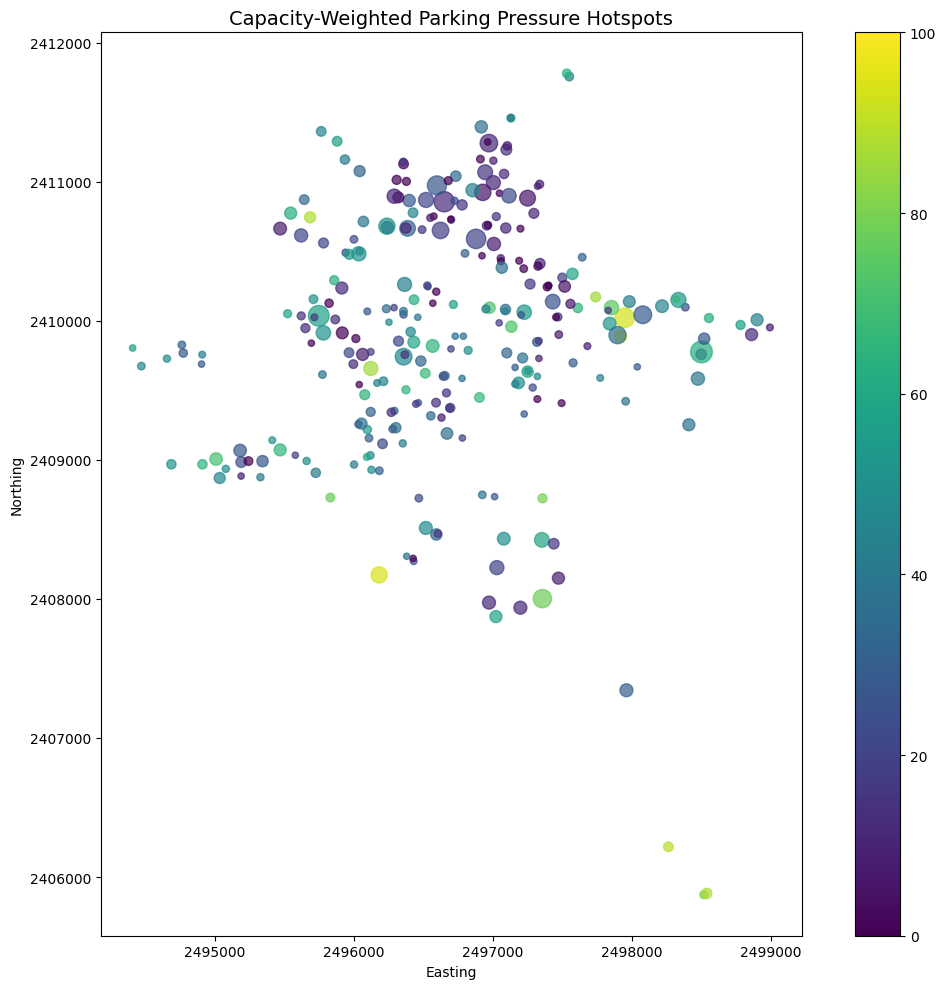

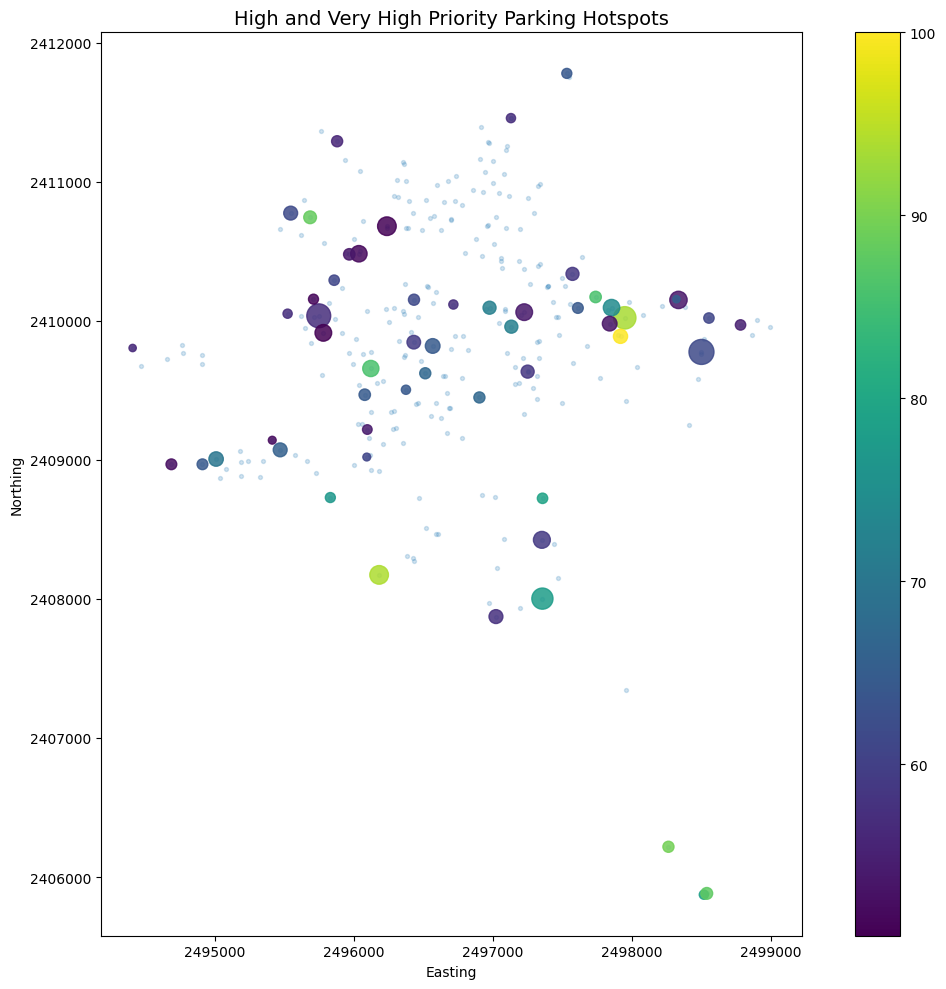

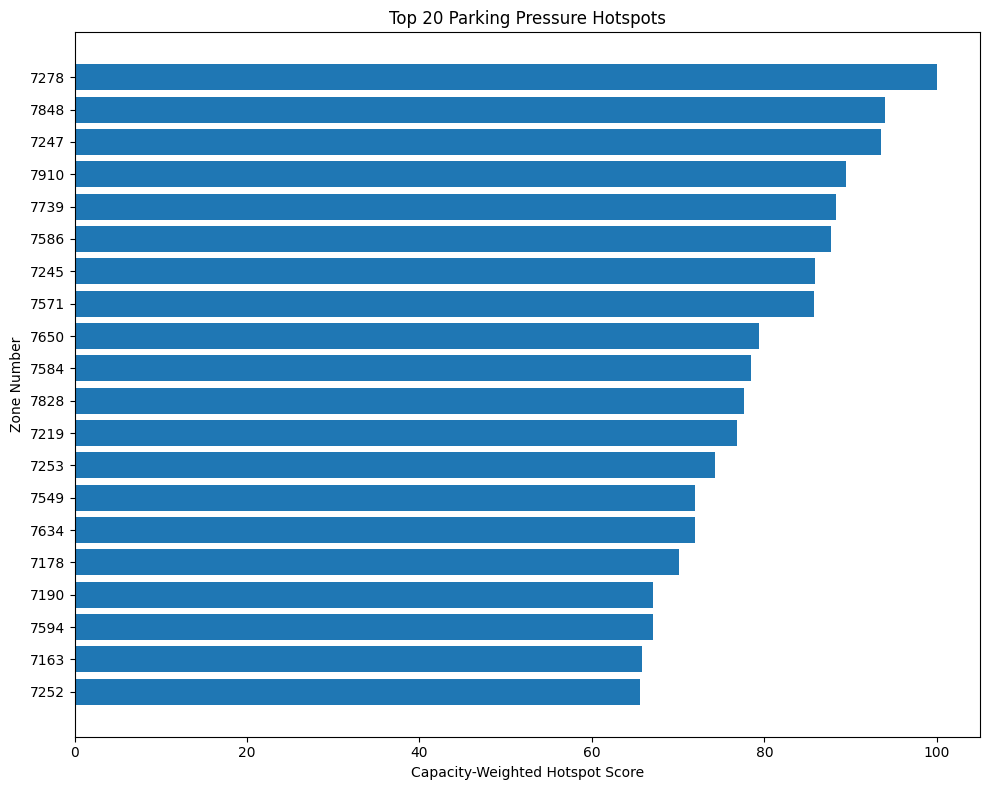


CELL 7 OUTPUT OBJECTS
parking_hotspot_gdf: 273 meaningful-capacity zone records
priority_hotspots: 55 High / Very High priority spatial zones
hotspot_ranking: 273 ranked zone records
CRS: EPSG:7899

CELL 7 SUMMARY
Parking pressure hotspots were identified using both current occupancy pressure and parking capacity.
The median parking capacity of 7.0 bays was used to prevent very small zones from dominating the hotspot ranking.
The resulting spatial hotspot dataset remains in EPSG:7899 and is ready for comparison with intervention/PO locations.

Cell 7 spatial parking hotspot analysis completed.


In [14]:
# ======================================================================
# CELL 7 - SPATIAL PARKING PRESSURE HOTSPOT ANALYSIS
# ======================================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt


print("=" * 70)
print("PARKING SENSOR DATASET - SPATIAL PRESSURE HOTSPOT ANALYSIS")
print("=" * 70)


# ----------------------------------------------------------------------
# 1. CHECK INPUT DATA
# ----------------------------------------------------------------------

required_columns = [
    "Zone_Number",
    "Parking_Bays",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Pressure_Score",
    "Pressure_Category",
    "geometry"
]

missing_columns = [
    col for col in required_columns
    if col not in parking_pressure_gdf.columns
]

if missing_columns:
    raise KeyError(
        f"parking_pressure_gdf is missing required columns: {missing_columns}"
    )


print("\nINPUT DATA CHECK")
print("-" * 70)

print("Zone records:", len(parking_pressure_gdf))
print("CRS:", parking_pressure_gdf.crs)
print(
    "Valid geometries:",
    parking_pressure_gdf.geometry.notna().sum()
)
print(
    "Missing pressure scores:",
    parking_pressure_gdf["Pressure_Score"].isna().sum()
)


# ----------------------------------------------------------------------
# 2. CREATE WORKING HOTSPOT DATASET
# ----------------------------------------------------------------------

parking_hotspots = parking_pressure_gdf.copy()

# Ensure numeric values
numeric_columns = [
    "Zone_Number",
    "Parking_Bays",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Pressure_Score"
]

for col in numeric_columns:
    parking_hotspots[col] = pd.to_numeric(
        parking_hotspots[col],
        errors="coerce"
    )


# ----------------------------------------------------------------------
# 3. REMOVE VERY SMALL ZONES FROM HOTSPOT PRIORITISATION
# ----------------------------------------------------------------------
# A zone with 1 or 2 bays can easily reach 100% pressure.
# Therefore, the median number of bays is used as a simple capacity
# threshold when identifying operationally meaningful hotspots.

capacity_threshold = parking_hotspots["Parking_Bays"].median()

meaningful_zones = parking_hotspots[
    parking_hotspots["Parking_Bays"] >= capacity_threshold
].copy()


print("\n" + "=" * 70)
print("MEANINGFUL CAPACITY FILTER")
print("=" * 70)

print("Median parking bays per zone:", capacity_threshold)
print(
    "Zones meeting capacity threshold:",
    len(meaningful_zones)
)
print(
    "Zones below capacity threshold:",
    len(parking_hotspots) - len(meaningful_zones)
)


# ----------------------------------------------------------------------
# 4. CREATE CAPACITY-WEIGHTED PRESSURE MEASURE
# ----------------------------------------------------------------------
# Pressure_Score shows how occupied a zone currently is.
# Parking_Bays represents the size/capacity of the zone.
#
# The weighted score helps distinguish:
#     100% pressure in a 2-bay zone
# from
#     90% pressure in a 25-bay zone.
#
# log1p is used so that very large zones do not completely dominate.

meaningful_zones["Capacity_Weight"] = np.log1p(
    meaningful_zones["Parking_Bays"]
)

meaningful_zones["Weighted_Pressure"] = (
    meaningful_zones["Pressure_Score"]
    * meaningful_zones["Capacity_Weight"]
)


# Normalise weighted pressure to 0-100 for easier interpretation

wp_min = meaningful_zones["Weighted_Pressure"].min()
wp_max = meaningful_zones["Weighted_Pressure"].max()

if wp_max > wp_min:
    meaningful_zones["Hotspot_Score"] = (
        (
            meaningful_zones["Weighted_Pressure"] - wp_min
        )
        /
        (
            wp_max - wp_min
        )
        * 100
    )
else:
    meaningful_zones["Hotspot_Score"] = 0.0


# ----------------------------------------------------------------------
# 5. CREATE HOTSPOT PRIORITY CATEGORIES
# ----------------------------------------------------------------------

meaningful_zones["Hotspot_Priority"] = pd.cut(
    meaningful_zones["Hotspot_Score"],
    bins=[
        -np.inf,
        25,
        50,
        75,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)


print("\n" + "=" * 70)
print("HOTSPOT PRIORITY DISTRIBUTION")
print("=" * 70)

print(
    meaningful_zones["Hotspot_Priority"]
    .value_counts()
    .reindex(
        ["Low", "Moderate", "High", "Very High"]
    )
)


# ----------------------------------------------------------------------
# 6. RANK PARKING HOTSPOTS
# ----------------------------------------------------------------------

hotspot_ranking = (
    meaningful_zones[
        [
            "Zone_Number",
            "Parking_Bays",
            "Present",
            "Unoccupied",
            "Present_Percentage",
            "Pressure_Score",
            "Hotspot_Score",
            "Hotspot_Priority"
        ]
    ]
    .sort_values(
        [
            "Hotspot_Score",
            "Parking_Bays"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("20 HIGHEST PRIORITY PARKING HOTSPOTS")
print("=" * 70)

print(
    hotspot_ranking
    .head(20)
    .round(
        {
            "Present_Percentage": 2,
            "Pressure_Score": 2,
            "Hotspot_Score": 2
        }
    )
    .to_string(index=False)
)


# ----------------------------------------------------------------------
# 7. IDENTIFY HIGH AND VERY HIGH PRIORITY HOTSPOTS
# ----------------------------------------------------------------------

priority_hotspots = meaningful_zones[
    meaningful_zones["Hotspot_Priority"].isin(
        [
            "High",
            "Very High"
        ]
    )
].copy()


print("\n" + "=" * 70)
print("HIGH PRIORITY SPATIAL HOTSPOTS")
print("=" * 70)

print(
    "High / Very High priority zones:",
    len(priority_hotspots)
)

print(
    "Parking bays represented:",
    int(priority_hotspots["Parking_Bays"].sum())
)

print(
    "Present bays:",
    int(priority_hotspots["Present"].sum())
)

print(
    "Unoccupied bays:",
    int(priority_hotspots["Unoccupied"].sum())
)


# ----------------------------------------------------------------------
# 8. TOP HOTSPOTS BY CAPACITY
# ----------------------------------------------------------------------

capacity_hotspots = (
    priority_hotspots[
        [
            "Zone_Number",
            "Parking_Bays",
            "Present",
            "Unoccupied",
            "Pressure_Score",
            "Hotspot_Score",
            "Hotspot_Priority"
        ]
    ]
    .sort_values(
        [
            "Parking_Bays",
            "Pressure_Score"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(20)
)


print("\n" + "=" * 70)
print("LARGEST HIGH-PRESSURE PARKING HOTSPOTS")
print("=" * 70)

print(
    capacity_hotspots
    .round(
        {
            "Pressure_Score": 2,
            "Hotspot_Score": 2
        }
    )
    .to_string(index=False)
)


# ----------------------------------------------------------------------
# 9. MAP ALL MEANINGFUL ZONES BY HOTSPOT SCORE
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 10)
)

meaningful_zones.plot(
    ax=ax,
    column="Hotspot_Score",
    markersize=np.maximum(
        meaningful_zones["Parking_Bays"] * 3,
        12
    ),
    legend=True,
    alpha=0.70
)

ax.set_title(
    "Capacity-Weighted Parking Pressure Hotspots",
    fontsize=14
)

ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

ax.ticklabel_format(
    style="plain",
    axis="both"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 10. MAP ONLY HIGH / VERY HIGH PRIORITY HOTSPOTS
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 10)
)

# Background zones
meaningful_zones.plot(
    ax=ax,
    markersize=8,
    alpha=0.20
)

# High-priority hotspots
priority_hotspots.plot(
    ax=ax,
    column="Hotspot_Score",
    markersize=np.maximum(
        priority_hotspots["Parking_Bays"] * 4,
        25
    ),
    legend=True,
    alpha=0.85
)

ax.set_title(
    "High and Very High Priority Parking Hotspots",
    fontsize=14
)

ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

ax.ticklabel_format(
    style="plain",
    axis="both"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 11. TOP 20 HOTSPOT BAR CHART
# ----------------------------------------------------------------------

top20_hotspots = hotspot_ranking.head(20).copy()

top20_hotspots["Zone_Label"] = (
    top20_hotspots["Zone_Number"]
    .astype(int)
    .astype(str)
)

top20_plot = (
    top20_hotspots
    .sort_values(
        "Hotspot_Score",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top20_plot["Zone_Label"],
    top20_plot["Hotspot_Score"]
)

plt.xlabel(
    "Capacity-Weighted Hotspot Score"
)

plt.ylabel(
    "Zone Number"
)

plt.title(
    "Top 20 Parking Pressure Hotspots"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 12. CREATE FINAL CELL 7 OUTPUT GEODATAFRAME
# ----------------------------------------------------------------------

parking_hotspot_gdf = meaningful_zones.copy()

parking_hotspot_gdf = gpd.GeoDataFrame(
    parking_hotspot_gdf,
    geometry="geometry",
    crs=parking_pressure_gdf.crs
)


print("\n" + "=" * 70)
print("CELL 7 OUTPUT OBJECTS")
print("=" * 70)

print(
    "parking_hotspot_gdf:",
    len(parking_hotspot_gdf),
    "meaningful-capacity zone records"
)

print(
    "priority_hotspots:",
    len(priority_hotspots),
    "High / Very High priority spatial zones"
)

print(
    "hotspot_ranking:",
    len(hotspot_ranking),
    "ranked zone records"
)

print(
    "CRS:",
    parking_hotspot_gdf.crs
)


# ----------------------------------------------------------------------
# 13. FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 7 SUMMARY")
print("=" * 70)

print(
    "Parking pressure hotspots were identified using both current "
    "occupancy pressure and parking capacity."
)

print(
    "The median parking capacity of",
    capacity_threshold,
    "bays was used to prevent very small zones from dominating "
    "the hotspot ranking."
)

print(
    "The resulting spatial hotspot dataset remains in",
    parking_hotspot_gdf.crs,
    "and is ready for comparison with intervention/PO locations."
)

print("\nCell 7 spatial parking hotspot analysis completed.")

PARKING SENSOR DATASET - INTERVENTION COMPARISON PREPARATION

INPUT DATA CHECK
----------------------------------------------------------------------
Meaningful-capacity hotspot zones: 273
High / Very High priority zones: 55
Ranked hotspot zones: 273
Hotspot CRS: EPSG:7899

GEOMETRY QUALITY CHECK
Missing geometries: 0
Empty geometries: 0
Valid geometries: 273

COMPARISON DATASET
Zone records: 273
CRS: EPSG:7899
Columns: ['Zone_Number', 'Parking_Bays', 'Unique_Locations', 'Present', 'Unoccupied', 'Present_Percentage', 'Unoccupied_Percentage', 'Pressure_Score', 'Capacity_Weight', 'Weighted_Pressure', 'Hotspot_Score', 'Hotspot_Priority', 'Mean_Latitude', 'Mean_Longitude', 'geometry']

HIGH-PRIORITY COMPARISON DATASET
High / Very High zones: 55
Parking bays represented: 1323
Currently present bays: 844
Currently unoccupied bays: 479

TOP 25 PARKING HOTSPOTS FOR INTERVENTION COMPARISON
 Hotspot_Rank  Zone_Number  Parking_Bays  Present  Unoccupied  Present_Percentage  Pressure_Score  Hotspot

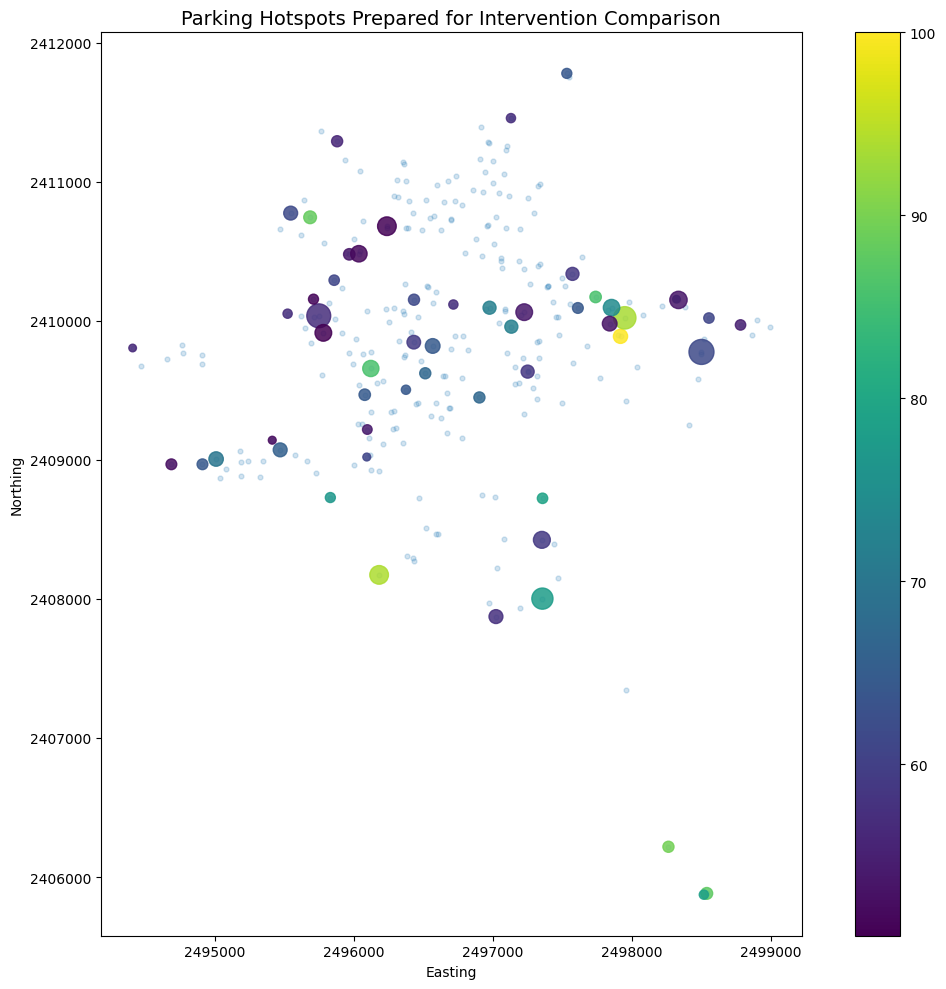


COORDINATE SYSTEMS READY FOR COMPARISON
Projected parking dataset: EPSG:7899
Latitude / longitude dataset: EPSG:4326

CELL 8 OUTPUT OBJECTS
parking_comparison_gdf: 273 zones
parking_priority_comparison: 55 High / Very High priority zones
parking_comparison_4326: 273 zones
parking_priority_4326: 55 High / Very High priority zones

CELL 8 SUMMARY
Parking hotspot results have been converted into a clean comparison-ready spatial dataset.
EPSG:7899 is retained for projected spatial and distance comparison.
EPSG:4326 copies were also created for intervention data provided as latitude and longitude.
High and Very High priority parking zones are now isolated for direct comparison with intervention / PO locations.

Cell 8 intervention comparison preparation completed.


In [16]:
# ======================================================================
# CELL 8 - PARKING HOTSPOTS: INTERVENTION COMPARISON PREPARATION
# ======================================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt


print("=" * 70)
print("PARKING SENSOR DATASET - INTERVENTION COMPARISON PREPARATION")
print("=" * 70)


# ----------------------------------------------------------------------
# 1. CHECK REQUIRED CELL 7 OUTPUTS
# ----------------------------------------------------------------------

required_objects = [
    "parking_hotspot_gdf",
    "priority_hotspots",
    "hotspot_ranking"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following Cell 7 outputs are missing. "
        "Please run Cell 7 first: "
        + ", ".join(missing_objects)
    )


print("\nINPUT DATA CHECK")
print("-" * 70)

print(
    "Meaningful-capacity hotspot zones:",
    len(parking_hotspot_gdf)
)

print(
    "High / Very High priority zones:",
    len(priority_hotspots)
)

print(
    "Ranked hotspot zones:",
    len(hotspot_ranking)
)

print(
    "Hotspot CRS:",
    parking_hotspot_gdf.crs
)


# ----------------------------------------------------------------------
# 2. CHECK GEOMETRY QUALITY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("GEOMETRY QUALITY CHECK")
print("=" * 70)

print(
    "Missing geometries:",
    parking_hotspot_gdf.geometry.isna().sum()
)

print(
    "Empty geometries:",
    parking_hotspot_gdf.geometry.is_empty.sum()
)

print(
    "Valid geometries:",
    parking_hotspot_gdf.geometry.notna().sum()
)


# ----------------------------------------------------------------------
# 3. CREATE CLEAN COMPARISON DATASET
# ----------------------------------------------------------------------
#
# This dataset keeps only the variables that will be useful when
# comparing parking pressure with intervention / PO locations.
# ----------------------------------------------------------------------

comparison_columns = [
    "Zone_Number",
    "Parking_Bays",
    "Unique_Locations",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Unoccupied_Percentage",
    "Pressure_Score",
    "Capacity_Weight",
    "Weighted_Pressure",
    "Hotspot_Score",
    "Hotspot_Priority",
    "Mean_Latitude",
    "Mean_Longitude",
    "geometry"
]


available_comparison_columns = [
    col for col in comparison_columns
    if col in parking_hotspot_gdf.columns
]


parking_comparison_gdf = (
    parking_hotspot_gdf[
        available_comparison_columns
    ]
    .copy()
)


parking_comparison_gdf = gpd.GeoDataFrame(
    parking_comparison_gdf,
    geometry="geometry",
    crs=parking_hotspot_gdf.crs
)


print("\n" + "=" * 70)
print("COMPARISON DATASET")
print("=" * 70)

print(
    "Zone records:",
    len(parking_comparison_gdf)
)

print(
    "CRS:",
    parking_comparison_gdf.crs
)

print(
    "Columns:",
    parking_comparison_gdf.columns.tolist()
)


# ----------------------------------------------------------------------
# 4. CREATE HIGH-PRIORITY COMPARISON DATASET
# ----------------------------------------------------------------------

parking_priority_comparison = (
    parking_comparison_gdf[
        parking_comparison_gdf[
            "Hotspot_Priority"
        ].isin(
            [
                "High",
                "Very High"
            ]
        )
    ]
    .copy()
)


print("\n" + "=" * 70)
print("HIGH-PRIORITY COMPARISON DATASET")
print("=" * 70)

print(
    "High / Very High zones:",
    len(parking_priority_comparison)
)

print(
    "Parking bays represented:",
    int(
        parking_priority_comparison[
            "Parking_Bays"
        ].sum()
    )
)

print(
    "Currently present bays:",
    int(
        parking_priority_comparison[
            "Present"
        ].sum()
    )
)

print(
    "Currently unoccupied bays:",
    int(
        parking_priority_comparison[
            "Unoccupied"
        ].sum()
    )
)


# ----------------------------------------------------------------------
# 5. ADD RANK TO COMPARISON DATASET
# ----------------------------------------------------------------------

parking_comparison_gdf = (
    parking_comparison_gdf
    .sort_values(
        [
            "Hotspot_Score",
            "Parking_Bays"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

parking_comparison_gdf[
    "Hotspot_Rank"
] = (
    np.arange(
        1,
        len(parking_comparison_gdf) + 1
    )
)


parking_priority_comparison = (
    parking_comparison_gdf[
        parking_comparison_gdf[
            "Hotspot_Priority"
        ].isin(
            [
                "High",
                "Very High"
            ]
        )
    ]
    .copy()
)


# ----------------------------------------------------------------------
# 6. DISPLAY TOP 25 COMPARISON-READY HOTSPOTS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 25 PARKING HOTSPOTS FOR INTERVENTION COMPARISON")
print("=" * 70)

display_columns = [
    "Hotspot_Rank",
    "Zone_Number",
    "Parking_Bays",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Pressure_Score",
    "Hotspot_Score",
    "Hotspot_Priority"
]


print(
    parking_comparison_gdf[
        display_columns
    ]
    .head(25)
    .round(
        {
            "Present_Percentage": 2,
            "Pressure_Score": 2,
            "Hotspot_Score": 2
        }
    )
    .to_string(index=False)
)


# ----------------------------------------------------------------------
# 7. SPATIAL EXTENT OF PARKING HOTSPOTS
# ----------------------------------------------------------------------

min_x, min_y, max_x, max_y = (
    parking_comparison_gdf.total_bounds
)

print("\n" + "=" * 70)
print("PARKING HOTSPOT SPATIAL EXTENT")
print("=" * 70)

print(
    "Minimum Easting:",
    round(min_x, 2)
)

print(
    "Minimum Northing:",
    round(min_y, 2)
)

print(
    "Maximum Easting:",
    round(max_x, 2)
)

print(
    "Maximum Northing:",
    round(max_y, 2)
)


# ----------------------------------------------------------------------
# 8. MAP COMPARISON-READY PARKING HOTSPOTS
# ----------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 10)
)


# All meaningful-capacity zones as context

parking_comparison_gdf.plot(
    ax=ax,
    markersize=12,
    alpha=0.20
)


# High and very high priority zones

parking_priority_comparison.plot(
    ax=ax,
    column="Hotspot_Score",
    markersize=np.maximum(
        parking_priority_comparison[
            "Parking_Bays"
        ] * 4,
        30
    ),
    legend=True,
    alpha=0.85
)


ax.set_title(
    "Parking Hotspots Prepared for Intervention Comparison",
    fontsize=14
)

ax.set_xlabel(
    "Easting"
)

ax.set_ylabel(
    "Northing"
)

ax.ticklabel_format(
    style="plain",
    axis="both"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 9. CREATE WGS84 VERSION FOR LATITUDE / LONGITUDE COMPARISON
# ----------------------------------------------------------------------
#
# EPSG:7899 remains the main projected CRS for distance analysis.
# A second EPSG:4326 version is useful if intervention coordinates
# are supplied as latitude / longitude.
# ----------------------------------------------------------------------

parking_comparison_4326 = (
    parking_comparison_gdf
    .to_crs(
        epsg=4326
    )
)


parking_priority_4326 = (
    parking_priority_comparison
    .to_crs(
        epsg=4326
    )
)


print("\n" + "=" * 70)
print("COORDINATE SYSTEMS READY FOR COMPARISON")
print("=" * 70)

print(
    "Projected parking dataset:",
    parking_comparison_gdf.crs
)

print(
    "Latitude / longitude dataset:",
    parking_comparison_4326.crs
)


# ----------------------------------------------------------------------
# 10. FINAL OUTPUT OBJECTS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 8 OUTPUT OBJECTS")
print("=" * 70)

print(
    "parking_comparison_gdf:",
    len(parking_comparison_gdf),
    "zones"
)

print(
    "parking_priority_comparison:",
    len(parking_priority_comparison),
    "High / Very High priority zones"
)

print(
    "parking_comparison_4326:",
    len(parking_comparison_4326),
    "zones"
)

print(
    "parking_priority_4326:",
    len(parking_priority_4326),
    "High / Very High priority zones"
)


# ----------------------------------------------------------------------
# 11. FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 8 SUMMARY")
print("=" * 70)

print(
    "Parking hotspot results have been converted into a clean "
    "comparison-ready spatial dataset."
)

print(
    "EPSG:7899 is retained for projected spatial and distance "
    "comparison."
)

print(
    "EPSG:4326 copies were also created for intervention data "
    "provided as latitude and longitude."
)

print(
    "High and Very High priority parking zones are now isolated "
    "for direct comparison with intervention / PO locations."
)

print(
    "\nCell 8 intervention comparison preparation completed."
)

In [18]:
# ======================================================================
# CELL 9 - FINAL VALIDATION, SUMMARY AND EXPORT
# ======================================================================

import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path


print("=" * 70)
print("PARKING SENSOR DATASET - FINAL VALIDATION AND EXPORT")
print("=" * 70)


# ----------------------------------------------------------------------
# 1. CHECK REQUIRED OUTPUTS FROM CELL 8
# ----------------------------------------------------------------------

required_objects = [
    "parking_comparison_gdf",
    "parking_priority_comparison",
    "parking_comparison_4326",
    "parking_priority_4326"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following Cell 8 outputs are missing. "
        "Please run Cell 8 first: "
        + ", ".join(missing_objects)
    )


print("\nINPUT DATA CHECK")
print("-" * 70)

print(
    "Comparison-ready zones:",
    len(parking_comparison_gdf)
)

print(
    "High / Very High priority zones:",
    len(parking_priority_comparison)
)

print(
    "Projected CRS:",
    parking_comparison_gdf.crs
)

print(
    "Geographic CRS:",
    parking_comparison_4326.crs
)


# ----------------------------------------------------------------------
# 2. FINAL DATA QUALITY CHECK
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)

important_columns = [
    "Zone_Number",
    "Parking_Bays",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Pressure_Score",
    "Hotspot_Score",
    "Hotspot_Priority",
    "Hotspot_Rank"
]

print("\nMissing values in important variables:")

for col in important_columns:
    if col in parking_comparison_gdf.columns:
        print(
            f"{col}:",
            parking_comparison_gdf[col].isna().sum()
        )


print(
    "\nMissing geometries:",
    parking_comparison_gdf.geometry.isna().sum()
)

print(
    "Empty geometries:",
    parking_comparison_gdf.geometry.is_empty.sum()
)

print(
    "Invalid geometries:",
    (~parking_comparison_gdf.geometry.is_valid).sum()
)

print(
    "Duplicate zone numbers:",
    parking_comparison_gdf[
        "Zone_Number"
    ].duplicated().sum()
)


# ----------------------------------------------------------------------
# 3. CHECK PARKING STATUS CONSISTENCY
# ----------------------------------------------------------------------
#
# At zone level, Present + Unoccupied should normally correspond
# to the number of parking bays represented by that zone.
# ----------------------------------------------------------------------

parking_comparison_gdf[
    "Status_Total"
] = (
    parking_comparison_gdf["Present"]
    + parking_comparison_gdf["Unoccupied"]
)

parking_comparison_gdf[
    "Status_Difference"
] = (
    parking_comparison_gdf["Parking_Bays"]
    - parking_comparison_gdf["Status_Total"]
)


status_mismatch = parking_comparison_gdf[
    parking_comparison_gdf[
        "Status_Difference"
    ] != 0
]


print("\n" + "=" * 70)
print("PARKING STATUS CONSISTENCY")
print("=" * 70)

print(
    "Zones checked:",
    len(parking_comparison_gdf)
)

print(
    "Zones where Present + Unoccupied equals Parking_Bays:",
    len(parking_comparison_gdf) - len(status_mismatch)
)

print(
    "Zones with a status difference:",
    len(status_mismatch)
)


if len(status_mismatch) > 0:
    print(
        "\nNote: A status difference may indicate records with "
        "another or unavailable current status."
    )


# ----------------------------------------------------------------------
# 4. FINAL PARKING HOTSPOT SUMMARY
# ----------------------------------------------------------------------

total_bays = (
    parking_comparison_gdf[
        "Parking_Bays"
    ].sum()
)

total_present = (
    parking_comparison_gdf[
        "Present"
    ].sum()
)

total_unoccupied = (
    parking_comparison_gdf[
        "Unoccupied"
    ].sum()
)

overall_present_percentage = (
    total_present / total_bays * 100
    if total_bays > 0
    else np.nan
)


priority_bays = (
    parking_priority_comparison[
        "Parking_Bays"
    ].sum()
)

priority_present = (
    parking_priority_comparison[
        "Present"
    ].sum()
)

priority_unoccupied = (
    parking_priority_comparison[
        "Unoccupied"
    ].sum()
)

priority_present_percentage = (
    priority_present / priority_bays * 100
    if priority_bays > 0
    else np.nan
)


print("\n" + "=" * 70)
print("FINAL PARKING HOTSPOT SUMMARY")
print("=" * 70)

print(
    "Meaningful-capacity zones:",
    len(parking_comparison_gdf)
)

print(
    "Parking bays represented:",
    int(total_bays)
)

print(
    "Currently present bays:",
    int(total_present)
)

print(
    "Currently unoccupied bays:",
    int(total_unoccupied)
)

print(
    "Overall present percentage:",
    round(overall_present_percentage, 2)
)


print("\nHIGH / VERY HIGH PRIORITY HOTSPOTS")
print("-" * 70)

print(
    "Priority zones:",
    len(parking_priority_comparison)
)

print(
    "Parking bays represented:",
    int(priority_bays)
)

print(
    "Present bays:",
    int(priority_present)
)

print(
    "Unoccupied bays:",
    int(priority_unoccupied)
)

print(
    "Present percentage:",
    round(priority_present_percentage, 2)
)


# ----------------------------------------------------------------------
# 5. DISPLAY FINAL TOP 20 HOTSPOTS
# ----------------------------------------------------------------------

final_display_columns = [
    "Hotspot_Rank",
    "Zone_Number",
    "Parking_Bays",
    "Present",
    "Unoccupied",
    "Present_Percentage",
    "Pressure_Score",
    "Hotspot_Score",
    "Hotspot_Priority"
]


print("\n" + "=" * 70)
print("FINAL TOP 20 PARKING HOTSPOTS")
print("=" * 70)

display(
    parking_comparison_gdf[
        final_display_columns
    ]
    .head(20)
    .round(
        {
            "Present_Percentage": 2,
            "Pressure_Score": 2,
            "Hotspot_Score": 2
        }
    )
)


# ----------------------------------------------------------------------
# 6. CREATE FINAL NON-SPATIAL SUMMARY TABLE
# ----------------------------------------------------------------------

parking_hotspot_summary = (
    parking_comparison_gdf
    .drop(
        columns=[
            "geometry",
            "Status_Total",
            "Status_Difference"
        ],
        errors="ignore"
    )
    .copy()
)


print("\n" + "=" * 70)
print("FINAL OUTPUT TABLE")
print("=" * 70)

print(
    "Rows:",
    len(parking_hotspot_summary)
)

print(
    "Columns:",
    len(parking_hotspot_summary.columns)
)


# ----------------------------------------------------------------------
# 7. PREPARE EXPORT FOLDER
# ----------------------------------------------------------------------

output_folder = Path(
    "parking_sensor_outputs"
)

output_folder.mkdir(
    exist_ok=True
)


# ----------------------------------------------------------------------
# 8. EXPORT FINAL CSV TABLE
# ----------------------------------------------------------------------

parking_hotspot_summary.to_csv(
    output_folder /
    "parking_hotspot_summary.csv",
    index=False
)


# ----------------------------------------------------------------------
# 9. EXPORT PROJECTED SPATIAL DATA
# ----------------------------------------------------------------------
#
# EPSG:7899 is retained for later spatial and distance analysis
# with the Product Owner / intervention data.
# ----------------------------------------------------------------------

parking_comparison_gdf.to_file(
    output_folder /
    "parking_hotspots_7899.geojson",
    driver="GeoJSON"
)

parking_priority_comparison.to_file(
    output_folder /
    "priority_parking_hotspots_7899.geojson",
    driver="GeoJSON"
)


# ----------------------------------------------------------------------
# 10. EXPORT LATITUDE / LONGITUDE VERSIONS
# ----------------------------------------------------------------------

parking_comparison_4326.to_file(
    output_folder /
    "parking_hotspots_4326.geojson",
    driver="GeoJSON"
)

parking_priority_4326.to_file(
    output_folder /
    "priority_parking_hotspots_4326.geojson",
    driver="GeoJSON"
)


# ----------------------------------------------------------------------
# 11. CONFIRM EXPORTED FILES
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EXPORTED FILES")
print("=" * 70)

for file in sorted(output_folder.iterdir()):
    print(file.name)


# ----------------------------------------------------------------------
# 12. FINAL NOTEBOOK SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PARKING SENSOR DATASET - PROCESSING COMPLETE")
print("=" * 70)

print(
    "The parking sensor dataset has been cleaned, validated, "
    "spatially prepared and aggregated to parking-zone level."
)

print(
    "Current parking pressure was calculated using the proportion "
    "of bays reporting Present status."
)

print(
    "Capacity-weighted hotspot scores were then used to identify "
    "operationally meaningful high-pressure parking zones."
)

print(
    "The final hotspot datasets are available in EPSG:7899 for "
    "spatial analysis and EPSG:4326 for latitude/longitude use."
)

print(
    "These outputs are now ready for later comparison with "
    "Product Owner streetscape intervention data."
)

print("\nCell 9 completed successfully.")
print("Parking Sensor dataset analysis is complete.")

PARKING SENSOR DATASET - FINAL VALIDATION AND EXPORT

INPUT DATA CHECK
----------------------------------------------------------------------
Comparison-ready zones: 273
High / Very High priority zones: 55
Projected CRS: EPSG:7899
Geographic CRS: EPSG:4326

FINAL DATA QUALITY CHECK

Missing values in important variables:
Zone_Number: 0
Parking_Bays: 0
Present: 0
Unoccupied: 0
Present_Percentage: 0
Pressure_Score: 0
Hotspot_Score: 0
Hotspot_Priority: 0
Hotspot_Rank: 0

Missing geometries: 0
Empty geometries: 0
Invalid geometries: 0
Duplicate zone numbers: 0

PARKING STATUS CONSISTENCY
Zones checked: 273
Zones where Present + Unoccupied equals Parking_Bays: 273
Zones with a status difference: 0

FINAL PARKING HOTSPOT SUMMARY
Meaningful-capacity zones: 273
Parking bays represented: 4823
Currently present bays: 1718
Currently unoccupied bays: 3105
Overall present percentage: 35.62

HIGH / VERY HIGH PRIORITY HOTSPOTS
----------------------------------------------------------------------
Pri

,Hotspot_Rank,Zone_Number,Parking_Bays,Present,Unoccupied,Present_Percentage,Pressure_Score,Hotspot_Score,Hotspot_Priority
0,1,7278.0,26,25,1,96.15,96.15,100.00,Very High
1,2,7848.0,45,35,10,77.78,77.78,93.97,Very High
2,3,7247.0,65,46,19,70.77,70.77,93.56,Very High
3,4,7910.0,16,16,0,100.00,100.00,89.41,Very High
4,5,7739.0,21,19,2,90.48,90.48,88.26,Very High
5,6,7586.0,18,17,1,94.44,94.44,87.75,Very High
6,7,7245.0,17,16,1,94.12,94.12,85.85,Very High
7,8,7571.0,34,26,8,76.47,76.47,85.79,Very High
8,9,7650.0,14,13,1,92.86,92.86,79.35,Very High
9,10,7584.0,11,11,0,100.00,100.00,78.41,Very High



FINAL OUTPUT TABLE
Rows: 273
Columns: 15

EXPORTED FILES
parking_hotspot_summary.csv
parking_hotspots_4326.geojson
parking_hotspots_7899.geojson
priority_parking_hotspots_4326.geojson
priority_parking_hotspots_7899.geojson

PARKING SENSOR DATASET - PROCESSING COMPLETE
The parking sensor dataset has been cleaned, validated, spatially prepared and aggregated to parking-zone level.
Current parking pressure was calculated using the proportion of bays reporting Present status.
Capacity-weighted hotspot scores were then used to identify operationally meaningful high-pressure parking zones.
The final hotspot datasets are available in EPSG:7899 for spatial analysis and EPSG:4326 for latitude/longitude use.
These outputs are now ready for later comparison with Product Owner streetscape intervention data.

Cell 9 completed successfully.
Parking Sensor dataset analysis is complete.
